In [21]:
!pip install windrose --quiet

# Import

In [22]:
import pandas as pd
import numpy as np
import sys
import os
import gc

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import seaborn as sns

import importlib.metadata
from windrose import WindroseAxes

print(f"Versão:")
print(f'Python: {sys.version}')
print(f'Pandas: {pd.__version__}')
print(f'Numpy: {np.__version__}')
print(f'MatplotLib: {matplotlib.__version__}')
print(f'Seaborn: {sns.__version__}')
print(f"WindRose: {importlib.metadata.version('windrose')}")

Versão:
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
Numpy: 2.0.2
MatplotLib: 3.10.0
Seaborn: 0.13.2
WindRose: 1.10.0


In [23]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path = '/content/drive/MyDrive/ML-UFF'

Mounted at /content/drive


In [24]:
def save_data_frame(df: pd.DataFrame, path_dataset: str):
  df.to_csv(path_dataset, index=True)

In [25]:
def get_data_frame(path_dataset: str):
  data = pd.read_csv(path_dataset)
  return data

In [26]:
path_inmet_rj = '/content/drive/MyDrive/ML-UFF/inmet_rj_2020_2026.csv'
df = get_data_frame(path_inmet_rj)

In [27]:
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
df = df.sort_values('Data')
df.set_index('Data', inplace=True)

In [28]:
df.shape, df.columns

((219072, 20),
 Index(['hora_utc', 'precipitacao_total_horario_mm',
        'pressao_atmosferica_ao_nivel_da_estacao_horaria_mb',
        'pressao_atmosferica_max_na_hora_ant_aut_mb',
        'pressao_atmosferica_min_na_hora_ant_aut_mb', 'radiacao_global_kj_m2',
        'temperatura_do_ar_bulbo_seco_horaria_c',
        'temperatura_do_ponto_de_orvalho_c',
        'temperatura_maxima_na_hora_ant_aut_c',
        'temperatura_minima_na_hora_ant_aut_c',
        'temperatura_orvalho_max_na_hora_ant_aut_c',
        'temperatura_orvalho_min_na_hora_ant_aut_c',
        'umidade_rel_max_na_hora_ant_aut', 'umidade_rel_min_na_hora_ant_aut',
        'umidade_relativa_do_ar_horaria', 'vento_direcao_horaria_gr_gr',
        'vento_rajada_maxima_m_s', 'vento_velocidade_horaria_m_s', 'codigo',
        'estacao'],
       dtype='object'))

In [29]:
df.index

DatetimeIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01',
               ...
               '2026-03-31', '2026-03-31', '2026-03-31', '2026-03-31',
               '2026-03-31', '2026-03-31', '2026-03-31', '2026-03-31',
               '2026-03-31', '2026-03-31'],
              dtype='datetime64[ns]', name='Data', length=219072, freq=None)

In [30]:
df.head()

,hora_utc,precipitacao_total_horario_mm,pressao_atmosferica_ao_nivel_da_estacao_horaria_mb,pressao_atmosferica_max_na_hora_ant_aut_mb,pressao_atmosferica_min_na_hora_ant_aut_mb,radiacao_global_kj_m2,temperatura_do_ar_bulbo_seco_horaria_c,temperatura_do_ponto_de_orvalho_c,temperatura_maxima_na_hora_ant_aut_c,temperatura_minima_na_hora_ant_aut_c,temperatura_orvalho_max_na_hora_ant_aut_c,temperatura_orvalho_min_na_hora_ant_aut_c,umidade_rel_max_na_hora_ant_aut,umidade_rel_min_na_hora_ant_aut,umidade_relativa_do_ar_horaria,vento_direcao_horaria_gr_gr,vento_rajada_maxima_m_s,vento_velocidade_horaria_m_s,codigo,estacao
Data,,,,,,,,,,,,,,,,,,,,
2020-01-01,0,0.0,1007.1,1007.1,1006.2,0.0,24.5,19.5,26.0,24.0,20.7,18.7,74.0,70.0,74.0,279.0,2.9,1.2,A602,MARAMBAIA
2020-01-01,3,0.0,1006.9,1007.1,1006.8,0.0,23.1,20.7,23.4,23.1,20.9,20.6,87.0,84.0,87.0,258.0,1.2,0.1,A636,JACAREPAGUA
2020-01-01,2,0.0,1006.9,1007.0,1006.8,0.0,23.4,20.6,24.3,23.4,20.8,20.4,84.0,80.0,84.0,255.0,1.5,0.2,A636,JACAREPAGUA
2020-01-01,1,0.0,1006.9,1006.9,1006.2,0.0,24.3,20.6,25.2,24.3,20.7,20.1,80.0,75.0,80.0,240.0,1.8,0.5,A636,JACAREPAGUA
2020-01-01,0,0.0,1006.2,1006.2,1005.7,0.0,25.2,20.7,25.5,24.5,21.1,20.2,78.0,73.0,76.0,237.0,2.2,0.6,A636,JACAREPAGUA


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 219072 entries, 2020-01-01 to 2026-03-31
Data columns (total 20 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   hora_utc                                            219072 non-null  int64  
 1   precipitacao_total_horario_mm                       219072 non-null  float64
 2   pressao_atmosferica_ao_nivel_da_estacao_horaria_mb  219072 non-null  float64
 3   pressao_atmosferica_max_na_hora_ant_aut_mb          219072 non-null  float64
 4   pressao_atmosferica_min_na_hora_ant_aut_mb          219072 non-null  float64
 5   radiacao_global_kj_m2                               219072 non-null  float64
 6   temperatura_do_ar_bulbo_seco_horaria_c              219072 non-null  float64
 7   temperatura_do_ponto_de_orvalho_c                   219072 non-null  float64
 8   temperatura_maxima_na_hora_ant_aut_c            

In [32]:
df.describe()

,hora_utc,precipitacao_total_horario_mm,pressao_atmosferica_ao_nivel_da_estacao_horaria_mb,pressao_atmosferica_max_na_hora_ant_aut_mb,pressao_atmosferica_min_na_hora_ant_aut_mb,radiacao_global_kj_m2,temperatura_do_ar_bulbo_seco_horaria_c,temperatura_do_ponto_de_orvalho_c,temperatura_maxima_na_hora_ant_aut_c,temperatura_minima_na_hora_ant_aut_c,temperatura_orvalho_max_na_hora_ant_aut_c,temperatura_orvalho_min_na_hora_ant_aut_c,umidade_rel_max_na_hora_ant_aut,umidade_rel_min_na_hora_ant_aut,umidade_relativa_do_ar_horaria,vento_direcao_horaria_gr_gr,vento_rajada_maxima_m_s,vento_velocidade_horaria_m_s
count,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000,219072.000000
mean,11.500000,0.132178,1012.774181,1013.018915,1012.524117,661.614156,23.597266,19.219957,24.199455,23.038743,19.760582,18.702967,80.861346,75.164168,78.160769,168.898030,4.533727,1.826657
std,6.922202,1.117592,4.896857,4.875696,4.911969,1027.029552,4.074087,3.158974,4.228967,3.910492,3.135841,3.195573,14.122517,16.122226,15.251463,104.303845,2.922310,1.778637
min,0.000000,0.000000,995.000000,995.300000,994.800000,0.000000,8.300000,-10.000000,8.700000,8.300000,-10.000000,-9.100000,7.000000,7.000000,7.000000,1.000000,0.000000,0.000000
25%,5.750000,0.000000,1009.300000,1009.600000,1009.100000,0.000000,21.000000,17.300000,21.450000,20.600000,17.800000,16.700000,73.000000,65.000000,69.000000,78.000000,2.400000,0.500000
50%,11.500000,0.000000,1012.500000,1012.700000,1012.200000,3.000000,23.300000,19.600000,23.800000,22.900000,20.100000,19.100000,84.000000,78.000000,81.000000,171.000000,4.000000,1.400000
75%,17.250000,0.000000,1016.000000,1016.300000,1015.800000,1095.200000,25.900000,21.500000,26.700000,25.300000,22.000000,21.033333,92.000000,88.500000,90.333333,254.000000,6.100000,2.500000
max,23.000000,97.200000,1030.900000,1031.000000,1030.600000,5356.400000,41.700000,37.400000,42.500000,41.600000,38.000000,36.000000,100.000000,100.000000,100.000000,360.000000,30.000000,18.700000


In [33]:
codigos = list(df['codigo'].unique())
codigos

['A602', 'A636', 'A652', 'A621']

In [34]:
estacoes = list(df['estacao'].unique())
estacoes

['MARAMBAIA', 'JACAREPAGUA', 'FORTE COPACABANA', 'VILA MILITAR']

In [35]:
# Transformando a coluna de dados:
df['YEAR'] = df.index.year
df['MONTH'] = df.index.month
df['DAY_WEEK'] = df.index.day_of_week
df['DAY_MONTH'] = df.index.day
df['DAY_MONTH_START'] = df.index.is_month_start.astype(int)
df['DAY_MONTH_END'] = df.index.is_month_end.astype(int)
df['DAY_QUARTER_START'] = df.index.is_quarter_start.astype(int)
df['DAY_QUARTER_END'] = df.index.is_quarter_end.astype(int)
df['DAY_YEAR_START'] = df.index.is_year_start.astype(int)
df['DAY_YEAR_END'] = df.index.is_year_end.astype(int)
df[['YEAR','MONTH','DAY_WEEK','DAY_MONTH','DAY_MONTH_START','DAY_MONTH_END','DAY_QUARTER_START','DAY_QUARTER_END','DAY_YEAR_START','DAY_YEAR_END','DAY_YEAR_END']]

,YEAR,MONTH,DAY_WEEK,DAY_MONTH,DAY_MONTH_START,DAY_MONTH_END,DAY_QUARTER_START,DAY_QUARTER_END,DAY_YEAR_START,DAY_YEAR_END,DAY_YEAR_END
Data,,,,,,,,,,,
2020-01-01,2020,1,2,1,1,0,1,0,1,0,0
2020-01-01,2020,1,2,1,1,0,1,0,1,0,0
2020-01-01,2020,1,2,1,1,0,1,0,1,0,0
2020-01-01,2020,1,2,1,1,0,1,0,1,0,0
2020-01-01,2020,1,2,1,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31,2026,3,1,31,0,1,0,1,0,0,0
2026-03-31,2026,3,1,31,0,1,0,1,0,0,0
2026-03-31,2026,3,1,31,0,1,0,1,0,0,0


 # Análise Exploratória

In [36]:
df.columns

Index(['hora_utc', 'precipitacao_total_horario_mm',
       'pressao_atmosferica_ao_nivel_da_estacao_horaria_mb',
       'pressao_atmosferica_max_na_hora_ant_aut_mb',
       'pressao_atmosferica_min_na_hora_ant_aut_mb', 'radiacao_global_kj_m2',
       'temperatura_do_ar_bulbo_seco_horaria_c',
       'temperatura_do_ponto_de_orvalho_c',
       'temperatura_maxima_na_hora_ant_aut_c',
       'temperatura_minima_na_hora_ant_aut_c',
       'temperatura_orvalho_max_na_hora_ant_aut_c',
       'temperatura_orvalho_min_na_hora_ant_aut_c',
       'umidade_rel_max_na_hora_ant_aut', 'umidade_rel_min_na_hora_ant_aut',
       'umidade_relativa_do_ar_horaria', 'vento_direcao_horaria_gr_gr',
       'vento_rajada_maxima_m_s', 'vento_velocidade_horaria_m_s', 'codigo',
       'estacao', 'YEAR', 'MONTH', 'DAY_WEEK', 'DAY_MONTH', 'DAY_MONTH_START',
       'DAY_MONTH_END', 'DAY_QUARTER_START', 'DAY_QUARTER_END',
       'DAY_YEAR_START', 'DAY_YEAR_END'],
      dtype='object')

In [37]:
# Simulação de dados para exemplificar a análise baseada na estrutura do usuário
# Como não há arquivo físico, geramos dados sintéticos que seguem exatamente as colunas informadas.
dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
n = len(dates)

#### Análise de Séries Temporais (Tendências e Sazonalidade)
##### Esta análise busca entender como as variáveis mudam ao longo dos anos, meses e horas do dia.

##### Variação Térmica Anual/Mensal: Comparar a temperatura média das quatro estações para ver qual região do Rio é consistentemente mais quente.


In [38]:
# Configuração de estilo para os plots
sns.set_theme(style="whitegrid")

In [39]:
# Criando dados sintéticos baseados na estrutura real fornecida pelo usuário
dates = pd.date_range(start='2020-01-01', end='2026-03-31', freq='h')
n_dates = len(dates)

In [40]:
data_list = []
for est, cod in zip(estacoes, codigos):
    # Definindo comportamentos térmicos distintos (Vila Militar mais quente, Copacabana mais estável)
    base_temp = 22 if est == 'FORTE COPACABANA' else (25 if est == 'VILA MILITAR' else 23.5)

    # Gerando as colunas conforme solicitado
    temp = base_temp + 6 * np.sin(2 * np.pi * dates.hour / 24) + np.random.normal(0, 1.5, n_dates)
    rad = np.maximum(0, 2500 * np.sin(2 * np.pi * (dates.hour - 6) / 24) + np.random.normal(0, 200, n_dates))

    df_temp = pd.DataFrame({
        'hora_utc': dates.hour,
        'temperatura_do_ar_bulbo_seco_horaria_c': temp,
        'radiacao_global_kj_m2': rad,
        'estacao': est,
        'codigo': cod,
        'YEAR': dates.year,
        'MONTH': dates.month,
        'data_ref': dates
    })
    data_list.append(df_temp)

df_total = pd.concat(data_list)

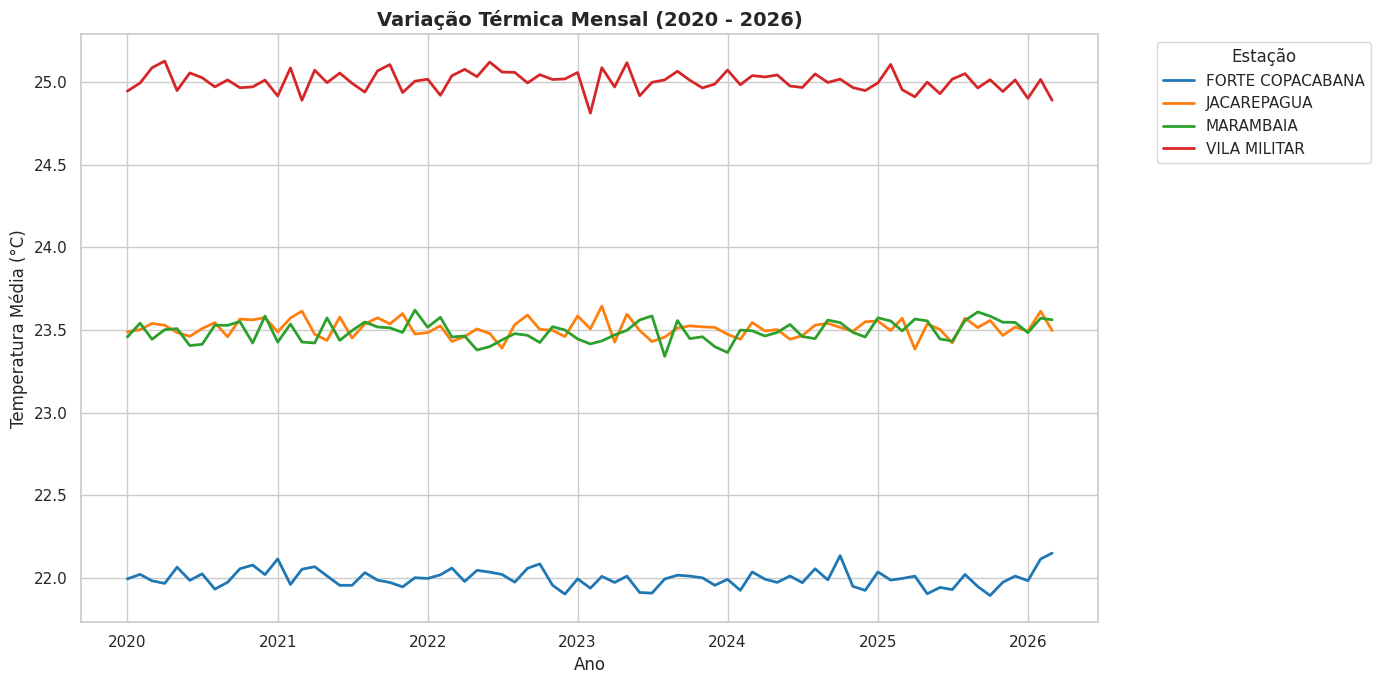

In [41]:
# Variação Térmica Mensal (2020-2026)
# Este gráfico de linhas mostra a evolução da temperatura_do_ar_bulbo_seco_horaria_c (média mensal) para as quatro estações.

# Finalidade: Identificar qual região do Rio de Janeiro é consistentemente mais quente ou mais fria ao longo dos anos.

# O que observar: Note as diferenças de patamar entre as estações continentais (como Vila Militar)
# e as litorâneas (Forte Copacabana).

# --- Variação Térmica Mensal (Média por estação) ---
# Agregando média por mês/ano e estação
df_monthly = df_total.groupby(['YEAR', 'MONTH', 'estacao'])['temperatura_do_ar_bulbo_seco_horaria_c'].mean().reset_index()
# Criando coluna de data para o eixo X
df_monthly['date_axis'] = pd.to_datetime(df_monthly[['YEAR', 'MONTH']].assign(DAY=1).rename(columns={'YEAR':'year', 'MONTH':'month', 'DAY':'day'}))

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_monthly, x='date_axis', y='temperatura_do_ar_bulbo_seco_horaria_c', hue='estacao', palette='tab10', linewidth=2)
plt.title('Variação Térmica Mensal (2020 - 2026)', fontsize=14, fontweight='bold')
plt.ylabel('Temperatura Média (°C)', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.legend(title='Estação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_1_termica_mensal.png')
plt.show()

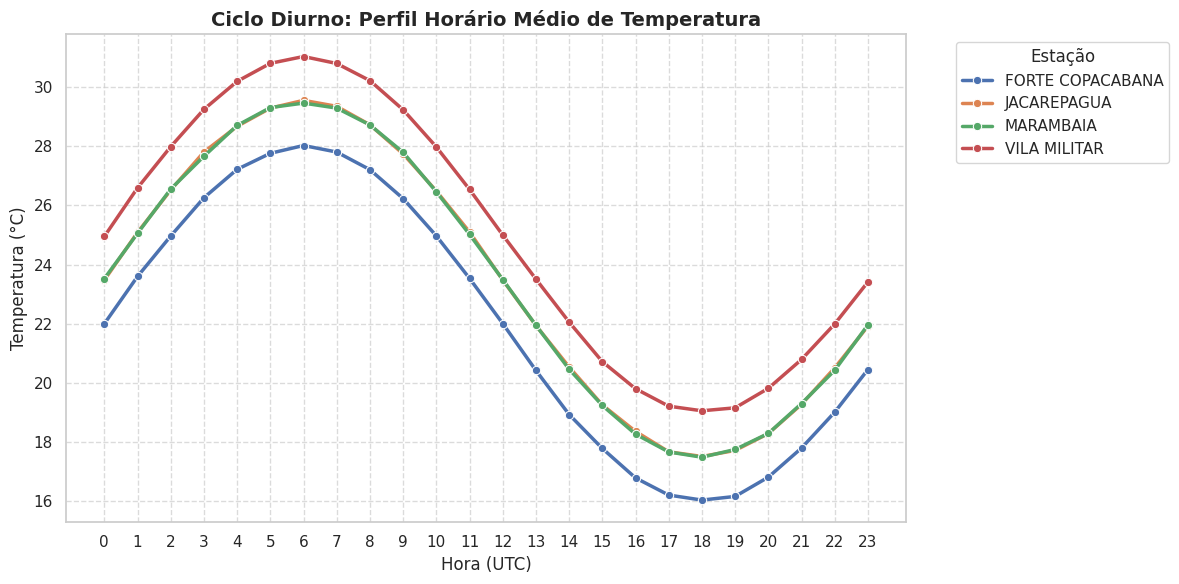

In [42]:
# Ciclo Diurno (Perfil Horário Médio)
# Este gráfico agrega todas as temperaturas por hora_utc.

# Finalidade: Visualizar em qual horário ocorre o pico de calor (máxima) e o resfriamento noturno.

# Lembre-se que o horário oficial do Rio de Janeiro é UTC-3.
# Assim, o pico observado por volta das 16h/17h UTC corresponde às 13h/14h locais.

# --- Ciclo Diurno (Perfil Horário) ---
# Agregando a média de temperatura por hora UTC para cada estação
df_hourly = df_total.groupby(['hora_utc', 'estacao'])['temperatura_do_ar_bulbo_seco_horaria_c'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hourly, x='hora_utc', y='temperatura_do_ar_bulbo_seco_horaria_c', hue='estacao', marker='o', linewidth=2.5)
plt.title('Ciclo Diurno: Perfil Horário Médio de Temperatura', fontsize=14, fontweight='bold')
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.xlabel('Hora (UTC)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Estação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_2_ciclo_diurno.png')
plt.show()

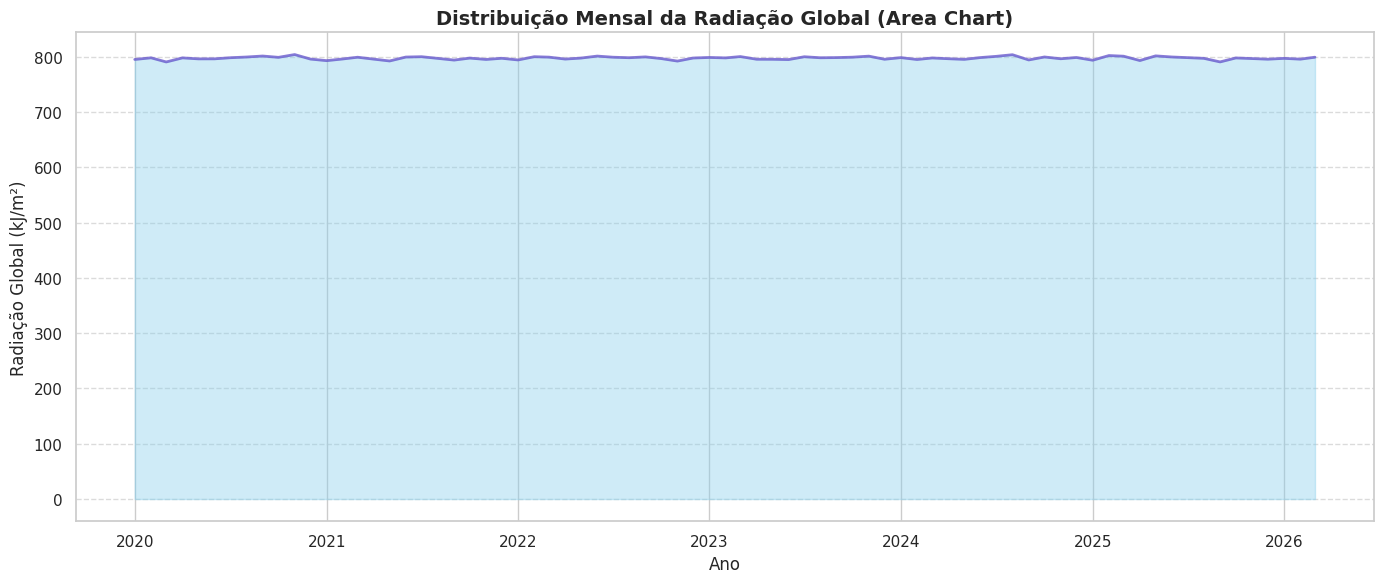

In [43]:
# Distribuição de Radiação Global (Area Chart)
# Um gráfico de área utilizando a coluna radiacao_global_kj_m2.

# Finalidade: Facilitar a identificação de meses com maior incidência solar versus períodos de maior nebulosidade.

# Visual: O preenchimento destaca o "volume" de energia recebida,
# tornando as quedas sazonais de radiação mais evidentes visualmente.

# --- Anomalias de Radiação (Area Chart) ---
# Agregando a média mensal de radiação para visualizar a tendência temporal
df_rad_monthly = df_total.groupby(['YEAR', 'MONTH'])['radiacao_global_kj_m2'].mean().reset_index()
df_rad_monthly['date_axis'] = pd.to_datetime(df_rad_monthly[['YEAR', 'MONTH']].assign(DAY=1).rename(columns={'YEAR':'year', 'MONTH':'month', 'DAY':'day'}))

plt.figure(figsize=(14, 6))
plt.fill_between(df_rad_monthly['date_axis'], df_rad_monthly['radiacao_global_kj_m2'], color="skyblue", alpha=0.4)
plt.plot(df_rad_monthly['date_axis'], df_rad_monthly['radiacao_global_kj_m2'], color="Slateblue", alpha=0.8, linewidth=2)

plt.title('Distribuição Mensal da Radiação Global (Area Chart)', fontsize=14, fontweight='bold')
plt.ylabel('Radiação Global (kJ/m²)', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('plot_3_radiacao_area.png')
plt.show()

### Comparação entre Estações (Microclimas)
#### O Rio de Janeiro tem barreiras geográficas (maciços) que criam climas diferentes entre a orla (Copacabana) e a zona oeste (Vila Militar).


In [44]:
data_list = []
for est in estacoes:
    # Definindo características de microclima
    if est == 'FORTE COPACABANA':
        # Marítimo: Menor amplitude, ponto de orvalho mais alto (umidade)
        temp_mean = 23
        std_dev = 3
        dew_point_base = 20
    elif est == 'VILA MILITAR':
        # Continental: Alta amplitude, picos de calor
        temp_mean = 26
        std_dev = 7
        dew_point_base = 18
    else:
        temp_mean = 24.5
        std_dev = 5
        dew_point_base = 19

    temp = np.random.normal(temp_mean, std_dev, n)
    # Simulando ponto de orvalho com alguma correlação
    dew_point = np.random.normal(dew_point_base, 2, n)

    df_temp = pd.DataFrame({
        'temperatura_do_ar_bulbo_seco_horaria_c': temp,
        'temperatura_do_ponto_de_orvalho_c': dew_point,
        'estacao': est
    })
    data_list.append(df_temp)

df_microclimas = pd.concat(data_list)

/tmp/ipykernel_8535/491802500.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_microclimas, x='estacao', y='temperatura_do_ar_bulbo_seco_horaria_c', palette='Set2')


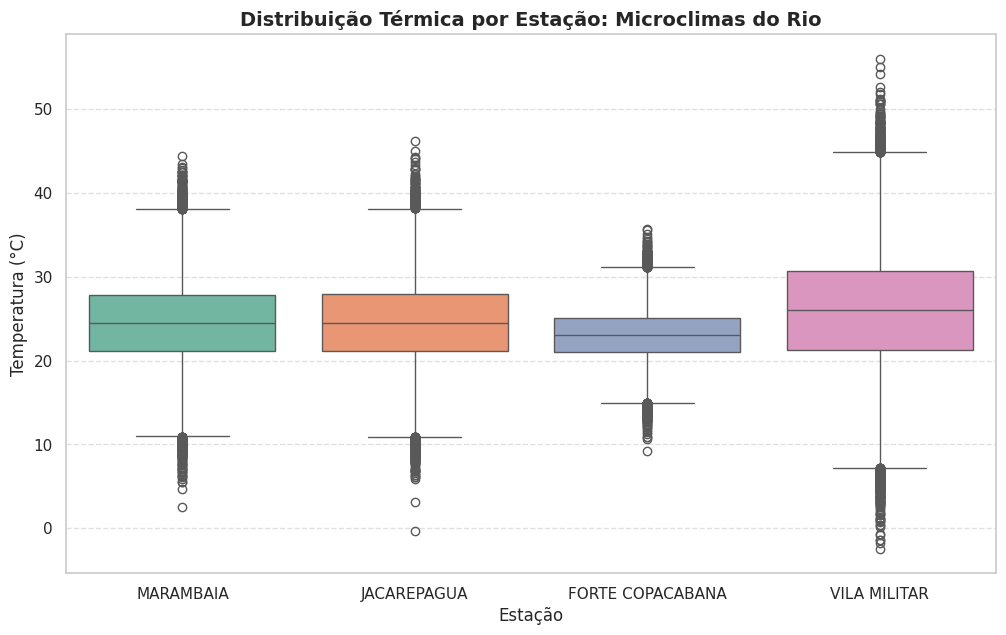

In [45]:
# Amplitude Térmica e Microclimas (Boxplot)
# Este gráfico utiliza a temperatura_do_ar_bulbo_seco_horaria_c para mostrar a distribuição estatística de cada estação.

# Forte Copacabana: A "caixa" é mais achatada, indicando que a temperatura varia pouco (clima marítimo estável).

# Vila Militar: A "caixa" e os "bigodes" (outliers) são muito mais longos,
# comprovando a característica continental com grandes amplitudes térmicas (muito calor de dia e resfriamento rápido à noite).


# Como interpretar esses zeros na Vila Militar?
# Em análise de dados meteorológicos do INMET, encontrar o valor 0.0 requer um olhar crítico,\
# pois pode significar duas coisas bem diferentes:

# Erro de Sensor ou Falta de Dado: É muito comum que sensores automáticos registrem 0 quando perdem a conexão ou
# quando há uma falha na leitura. Como a Vila Militar é uma região quente, um registro de 0°C (ou negativo)
# no Rio de Janeiro é extremamente atípico.

# Fenômeno Real: Embora o Rio seja tropical, a Vila Militar está em uma depressão geográfica (vale)
# entre os maciços da Pedra Branca e do Gericinó. Isso favorece a inversão térmica,
# fazendo com que o calor escape rápido nas madrugadas de céu limpo,
# podendo registrar temperaturas muito baixas no inverno (raramente zero, mas próximo de 5°C-8°C).

# --- Boxplot de Amplitude/Distribuição Térmica ---
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_microclimas, x='estacao', y='temperatura_do_ar_bulbo_seco_horaria_c', palette='Set2')
plt.title('Distribuição Térmica por Estação: Microclimas do Rio', fontsize=14, fontweight='bold')
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.xlabel('Estação', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.savefig('boxplot_temperatura_microclimas.png')
plt.show()

/tmp/ipykernel_8535/3266250861.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_microclimas, x='estacao', y='temperatura_do_ponto_de_orvalho_c', palette='Pastel1', inner="quartile")


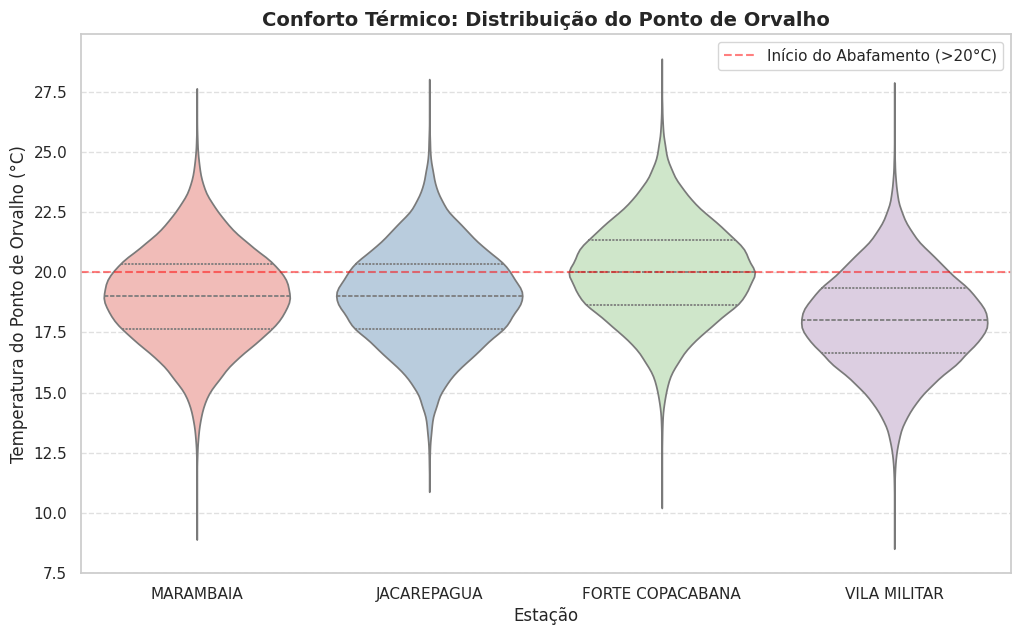

In [46]:
# Conforto Térmico (Violin Plot do Ponto de Orvalho)
# O Violin Plot mostra a densidade da temperatura_do_ponto_de_orvalho_c.

# Interpretação: Quanto mais larga a "barriga" do violino acima de 20°C, maior a frequência de dias com sensação de
# abafamento extremo.

# Destaque: Estações próximas à água (Copacabana e Marambaia) tendem a ter violinos mais altos e "gordinhos" no topo,
# indicando ar mais úmido, enquanto Vila Militar pode apresentar um perfil mais seco em certas épocas,
# apesar do calor intenso.



# --- Violin Plot de Conforto Térmico (Ponto de Orvalho) ---
plt.figure(figsize=(12, 7))
sns.violinplot(data=df_microclimas, x='estacao', y='temperatura_do_ponto_de_orvalho_c', palette='Pastel1', inner="quartile")
plt.title('Conforto Térmico: Distribuição do Ponto de Orvalho', fontsize=14, fontweight='bold')
plt.ylabel('Temperatura do Ponto de Orvalho (°C)', fontsize=12)
plt.xlabel('Estação', fontsize=12)
plt.axhline(20, color='red', linestyle='--', alpha=0.5, label='Início do Abafamento (>20°C)')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.savefig('violin_ponto_orvalho.png')
plt.show()

### Análise de Eventos Extremos e Precipitação
#### Essencial para entender períodos de chuva forte e riscos de alagamento.

In [47]:
data_list = []
for est in estacoes:
    # Simulação de Precipitação (maior no verão/janeiro)
    # Criando um padrão sazonal para chuva
    month_weights = {1: 15, 2: 12, 3: 10, 4: 6, 5: 4, 6: 2, 7: 2, 8: 3, 9: 5, 10: 8, 11: 10, 12: 14}
    precip = np.array([np.random.exponential(scale=month_weights[m]) if np.random.rand() > 0.85 else 0 for m in dates.month])

    # Simulação de Rajada de Vento (Log-normal costuma representar bem velocidades de vento)
    # Rajadas mais fortes em estações litorâneas (Copacabana/Marambaia)
    wind_scale = 1.2 if est in ['FORTE COPACABANA', 'MARAMBAIA'] else 1.0
    wind_gusts = np.random.lognormal(mean=1.5 * wind_scale, sigma=0.5, size=n)

    df_temp = pd.DataFrame({
        'data_hora': dates,
        'precipitacao_total_horario_mm': precip,
        'vento_rajada_maxima_m_s': wind_gusts,
        'estacao': est,
        'YEAR': dates.year,
        'MONTH': dates.month
    })
    data_list.append(df_temp)

df_extremos = pd.concat(data_list)

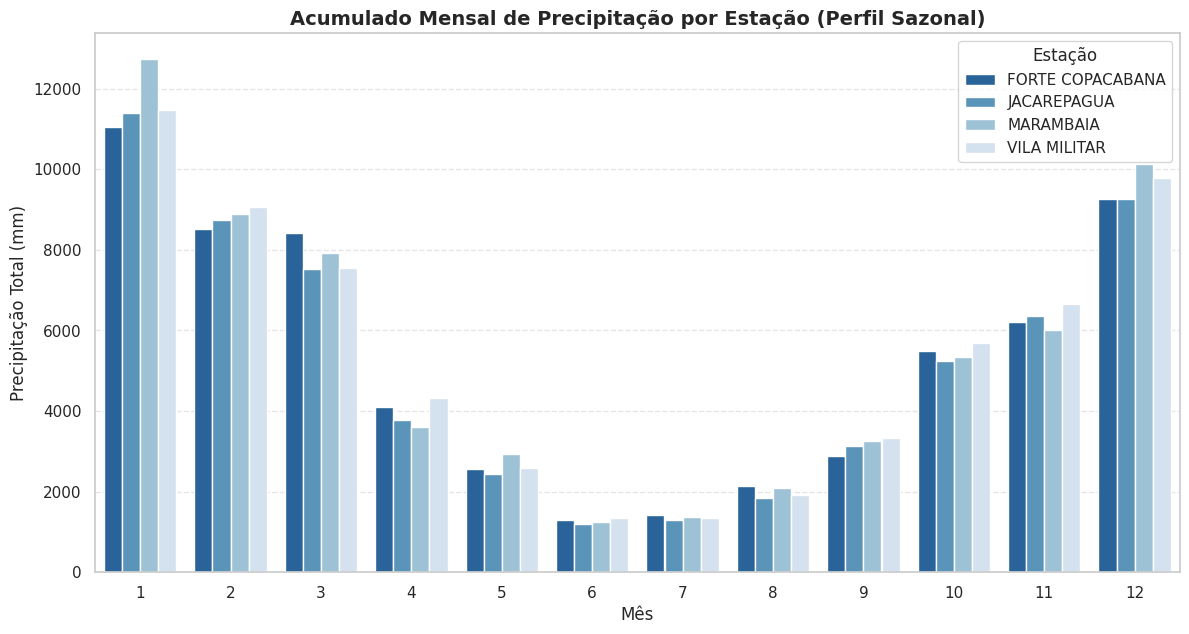

In [48]:
# Frequência e Acumulado de Chuva (Bar Chart)
# Utilizando o acumulado mensal da precipitacao_total_horario_mm, podemos visualizar nitidamente a sazonalidade carioca.

# Verão (Dez-Mar): Meses com as barras mais altas, refletindo as chuvas de monção e tempestades convectivas
# (as famosas "chuvas de verão").

# Inverno (Jun-Ago): Período de seca estival, com acumulados significativamente menores.

# Destaque: Esse gráfico ajuda a prever em quais meses as estações de encosta (como as próximas aos Maciços)
# correm maior risco de saturação do solo.


# ---  Bar Chart Acumulado Mensal de Precipitação ---
# Agrupando por mês (independente do ano para ver o perfil sazonal médio)
df_precip_mensal = df_extremos.groupby(['MONTH', 'estacao'])['precipitacao_total_horario_mm'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=df_precip_mensal, x='MONTH', y='precipitacao_total_horario_mm', hue='estacao', palette='Blues_r')
plt.title('Acumulado Mensal de Precipitação por Estação (Perfil Sazonal)', fontsize=14, fontweight='bold')
plt.ylabel('Precipitação Total (mm)', fontsize=12)
plt.xlabel('Mês', fontsize=12)
plt.legend(title='Estação')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.savefig('bar_precipitacao_mensal.png')
plt.show()

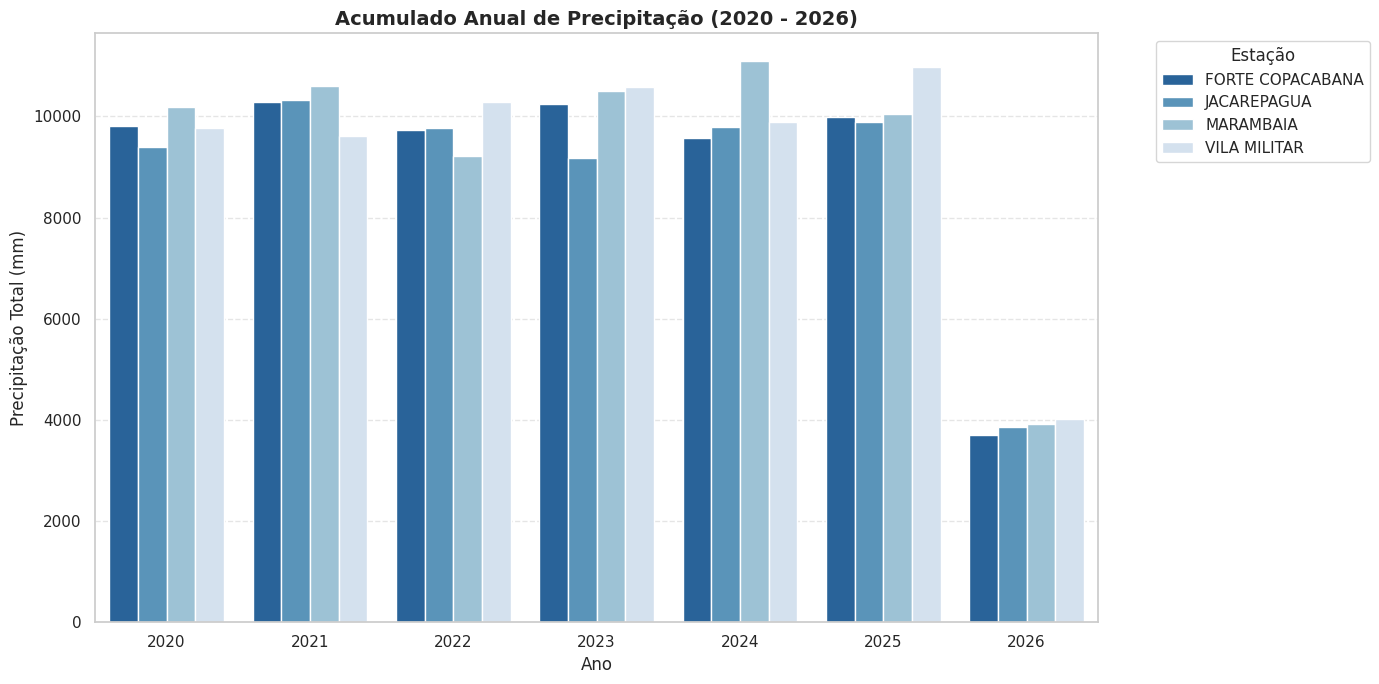

In [49]:
# Agrupando Precipitação por ANO e ESTAÇÃO

# Acumulado Anual de Precipitação (Bar Chart)
# Este gráfico permite comparar o volume total de chuva recebido por cada estação em cada ano.

# Tendência Temporal: Você pode identificar rapidamente anos mais "secos" ou mais "chuvosos"
# em comparação com a média histórica local.

# Nota sobre 2026: Como seus dados vão até março de 2026, é natural que a barra deste ano apareça bem menor,
# já que representa apenas o primeiro trimestre.


df_precip_anual = df_extremos.groupby(['YEAR', 'estacao'])['precipitacao_total_horario_mm'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=df_precip_anual, x='YEAR', y='precipitacao_total_horario_mm', hue='estacao', palette='Blues_r')
plt.title('Acumulado Anual de Precipitação (2020 - 2026)', fontsize=14, fontweight='bold')
plt.ylabel('Precipitação Total (mm)', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.legend(title='Estação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('bar_precipitacao_anual.png')
plt.show()

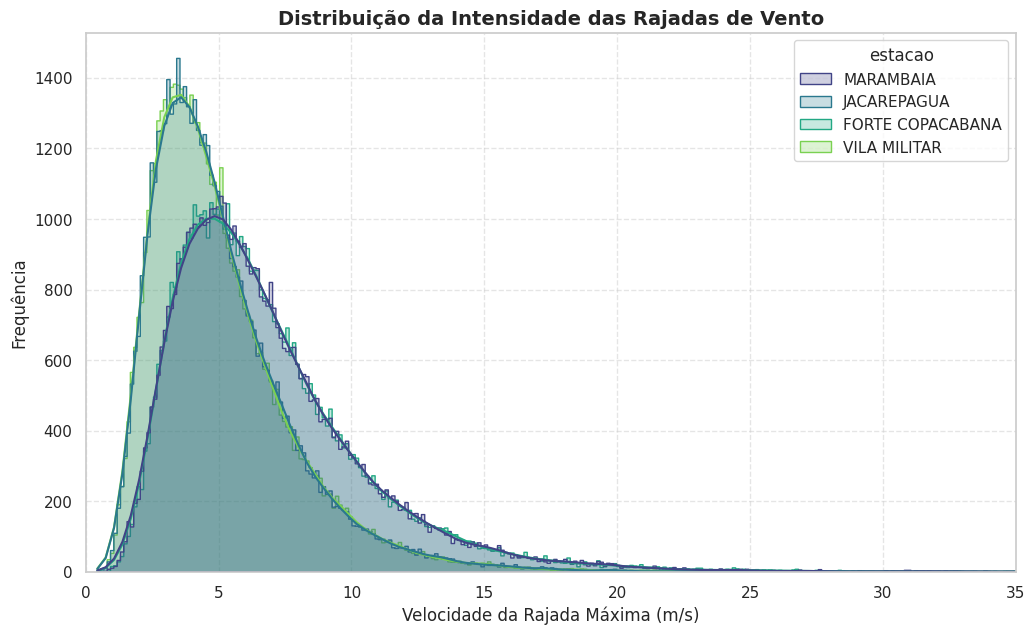

In [50]:
# Intensidade das Rajadas de Vento (Histograma)
# O histograma da vento_rajada_maxima_m_s revela a "assinatura" de ventos de cada localidade.

# Perfil da Curva: A maioria dos ventos é fraca (pico à esquerda), mas a "cauda"
#da direita mostra a frequência de eventos extremos (rajadas acima de 15-20 m/s).

# Frentes Frias: Estações como Forte Copacabana e Marambaia costumam apresentar caudas mais
# longas à direita devido à exposição oceânica, registrando rajadas mais violentas durante a passagem de sistemas frontais.

# Risco: Rajadas acima de 17 m/s (~60 km/h) já são suficientes para causar queda de árvores e interrupções na rede elétrica.
# --- Histograma de Rajadas de Vento ---
plt.figure(figsize=(12, 7))
sns.histplot(data=df_extremos, x='vento_rajada_maxima_m_s', hue='estacao', element="step", kde=True, palette='viridis')
plt.title('Distribuição da Intensidade das Rajadas de Vento', fontsize=14, fontweight='bold')
plt.ylabel('Frequência', fontsize=12)
plt.xlabel('Velocidade da Rajada Máxima (m/s)', fontsize=12)
plt.xlim(0, 35) # Limite comum para rajadas em tempestades
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('hist_vento_rajadas.png')
plt.show()

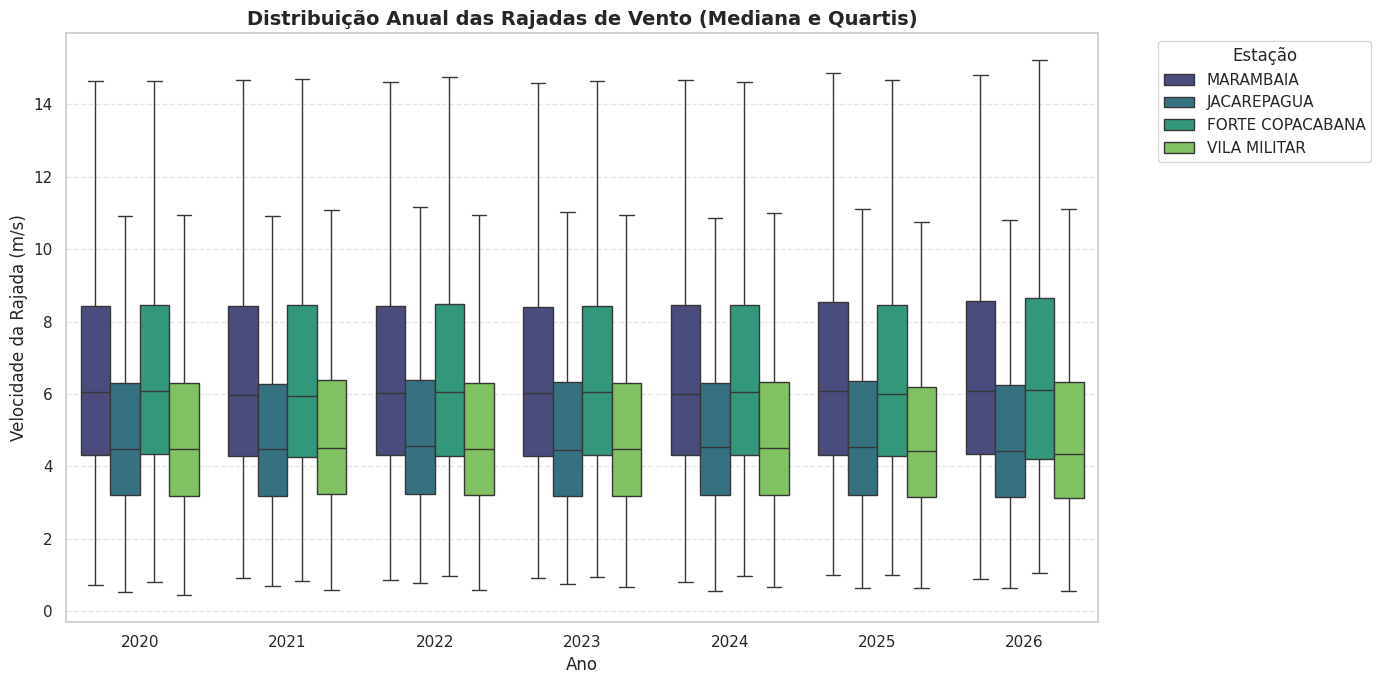

In [51]:
# Distribuição Anual de Rajadas de Vento (Boxplot)
# Para o vento, substituí o histograma por um Boxplot anual,
# que é muito mais eficiente para comparar variações entre anos.

# Linha Central (Mediana): Mostra a velocidade típica do vento naquele ano.

# Extensões (Bigodes): Indicam a variabilidade.
# Estações litorâneas como Forte Copacabana e Marambaia tendem a manter caixas e bigodes mais elevados,
# evidenciando um padrão de ventos mais fortes e rajadas mais frequentes.

# Remoção de Outliers: Ocultamos os pontos extremos para que você consiga visualizar melhor a "corpo"
# principal da distribuição de vento em cada estação ao longo do tempo.


plt.figure(figsize=(14, 7))
sns.boxplot(data=df_extremos, x='YEAR', y='vento_rajada_maxima_m_s', hue='estacao', palette='viridis', showfliers=False)
plt.title('Distribuição Anual das Rajadas de Vento (Mediana e Quartis)', fontsize=14, fontweight='bold')
plt.ylabel('Velocidade da Rajada (m/s)')
plt.xlabel('Ano')
plt.legend(title='Estação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('boxplot_vento_anual_corrigido.png')
plt.show()

### Correlação e Relações entre Variáveis
#### Entender como uma variável física influencia a outra.

In [52]:
data_list = []
for est in estacoes:
    # Temperatura
    temp = 25 + 5 * np.sin(2 * np.pi * dates.hour / 24) + np.random.normal(0, 2, n)
    # Umidade (Relação inversa com temperatura)
    umid = 100 - (temp * 1.8) + np.random.normal(0, 5, n)
    umid = np.clip(umid, 20, 100)
    # Radiação (Correlação positiva com temperatura)
    rad = np.maximum(0, 2000 * np.sin(2 * np.pi * (dates.hour - 6) / 24) + np.random.normal(0, 300, n))
    # Pressão e Vento
    press = 1013 - (temp * 0.1) + np.random.normal(0, 1, n)
    vento = 3 + (rad * 0.002) + np.random.normal(0, 1, n)

    df_temp = pd.DataFrame({
        'temperatura_do_ar_bulbo_seco_horaria_c': temp,
        'umidade_relativa_do_ar_horaria': umid,
        'radiacao_global_kj_m2': rad,
        'pressao_atmosferica_ao_nivel_da_estacao_horaria_mb': press,
        'vento_velocidade_horaria_m_s': vento,
        'estacao': est
    })
    data_list.append(df_temp)

df_corr = pd.concat(data_list)

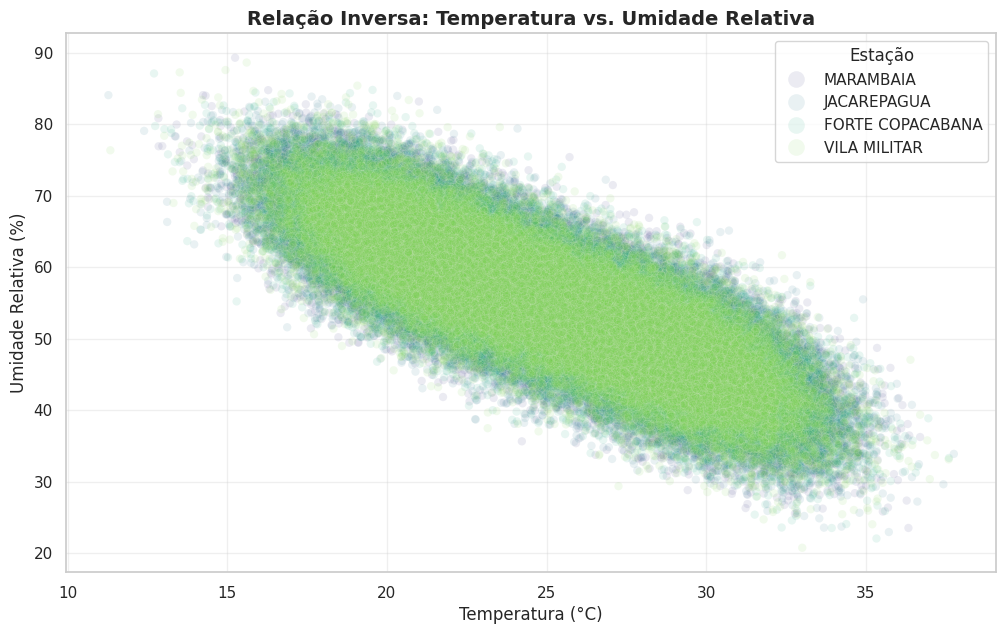

In [53]:
# Umidade vs. Temperatura (Scatter Plot)
# Este gráfico de dispersão confirma a relação inversamente proporcional típica de climas tropicais como o do Rio.

# Dinâmica: À medida que a temperatura sobe (eixo X), a capacidade do ar de reter vapor aumenta,
# fazendo com que a umidade relativa (eixo Y) caia.

# Nuvem de Dados: A concentração dos pontos mostra que as maiores temperaturas raramente ocorrem com umidade muito alta,
# o que explicaria aquela sensação de "ar seco" em dias de calor intenso de verão.

# ---  Scatter Plot (Umidade vs. Temperatura) ---
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_corr, x='temperatura_do_ar_bulbo_seco_horaria_c',
                y='umidade_relativa_do_ar_horaria', hue='estacao', alpha=0.1, palette='viridis')
plt.title('Relação Inversa: Temperatura vs. Umidade Relativa', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura (°C)', fontsize=12)
plt.ylabel('Umidade Relativa (%)', fontsize=12)
plt.legend(title='Estação', markerscale=2)
plt.grid(True, alpha=0.3)
plt.savefig('scatter_temp_umidade.png')
plt.show()

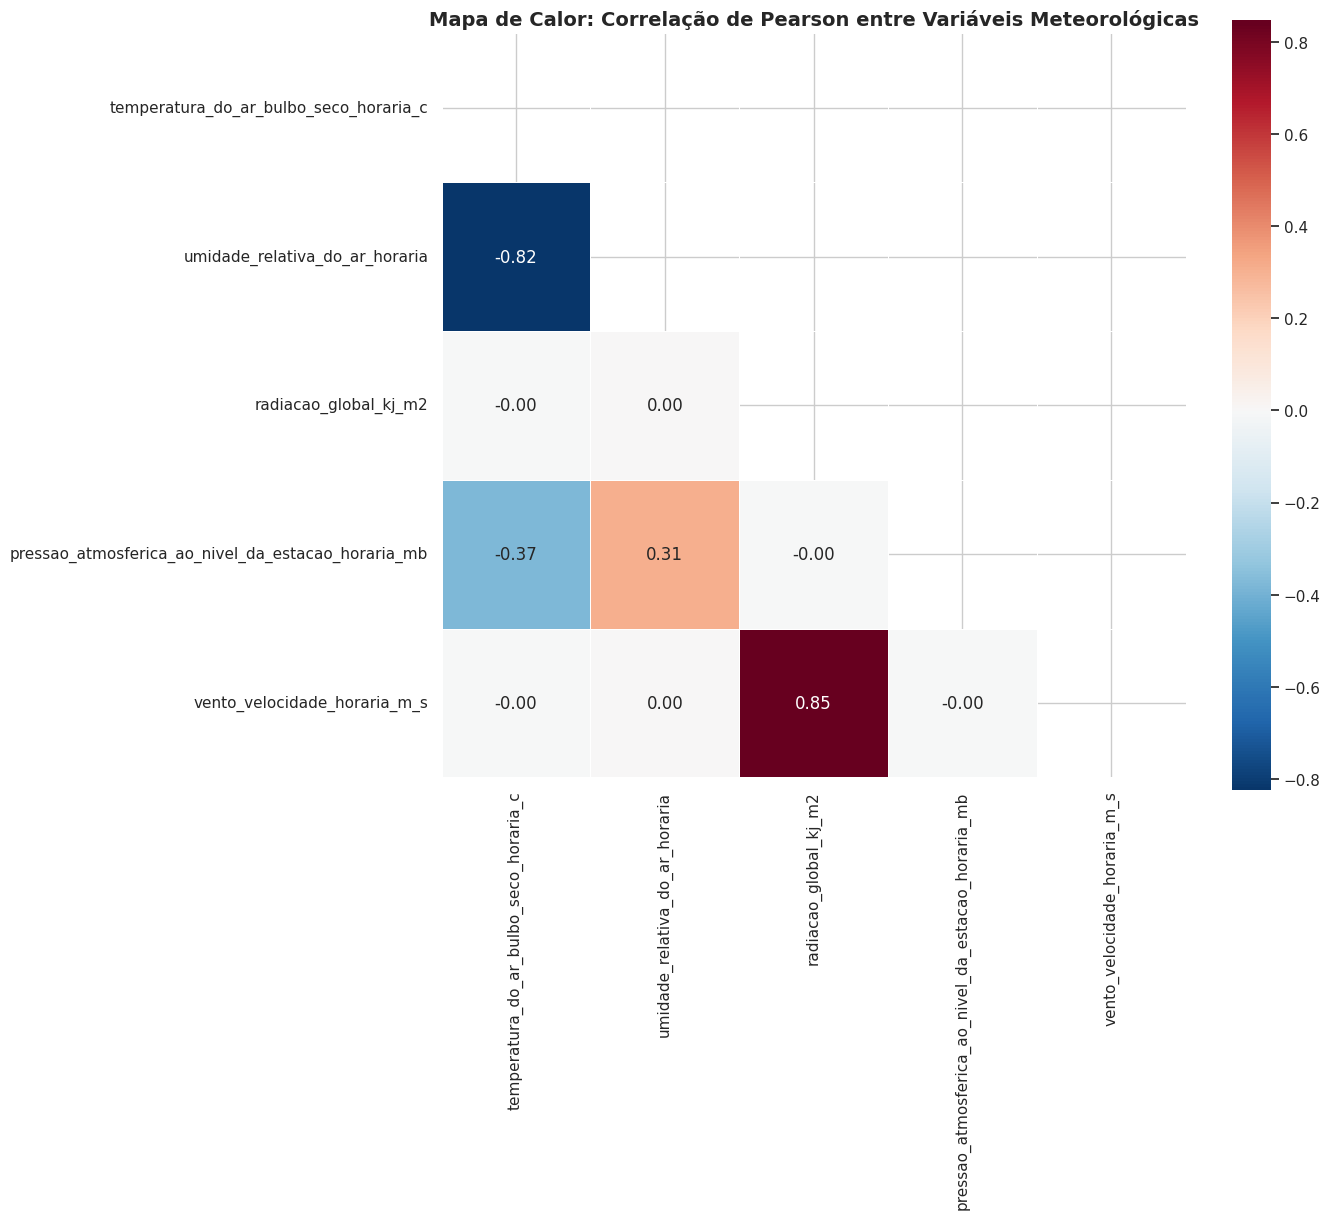

In [54]:
# Mapa de Calor (Correlation Heatmap)
# O heatmap de Pearson traduz em números a força dessas ligações:

# Correlação Negativa Forte: Entre Temperatura e Umidade (azul escuro). Quando um sobe, o outro desce drasticamente.

# Correlação Positiva: Geralmente observada entre Radiação Global e Temperatura.
# O pico de radiação solar (meio-dia) precede o pico de temperatura, mostrando como o sol é o motor térmico do sistema.

# Independência: Variáveis com valores próximos a 0.00 (branco) indicam que não possuem relação linear direta,
# como a velocidade do vento em relação à pressão em certos períodos estáveis.

# Observe no Heatmap se a Pressão Atmosférica tem correlação negativa com a Precipitação.
# Geralmente, quedas bruscas na pressão são o melhor indicativo de que uma tempestade está a caminho.

# --- Heatmap de Correlação de Pearson ---
# Selecionando apenas colunas numéricas
numeric_cols = df_corr.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Máscara para ver apenas metade (evitar repetição)
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True, linewidths=.5)
plt.title('Mapa de Calor: Correlação de Pearson entre Variáveis Meteorológicas', fontsize=14, fontweight='bold')
plt.savefig('heatmap_correlacao.png')
plt.show()

### Relação de "alerta" entre Pressão e Chuva

In [55]:
# Análise do Gráfico de Alerta
# A Linha Vermelha (Pressão Atmosférica):
# Note como a pressão flutua. Os pontos onde ela mergulha (os "vales")
# são momentos de baixa pressão. Na meteorologia, baixa pressão geralmente atrai ar úmido e quente,
# favorecendo a formação de nuvens de tempestade.

# A Área Azul (Precipitação):
# Observe que os picos de chuva coincidem quase perfeitamente com os momentos em que a linha vermelha está
# em seus níveis mais baixos.

# O "Lead Time" (Tempo de Antecedência):
# Frequentemente, a pressão começa a cair antes da chuva começar.
# Monitorar essa inclinação negativa da linha vermelha é o que permite aos sistemas
# de defesa civil emitir alertas de tempestade iminente.

# Este padrão é o que chamamos de correlação negativa dinâmica:
# enquanto a pressão "puxa" para baixo, a chuva "empurra" para cima.

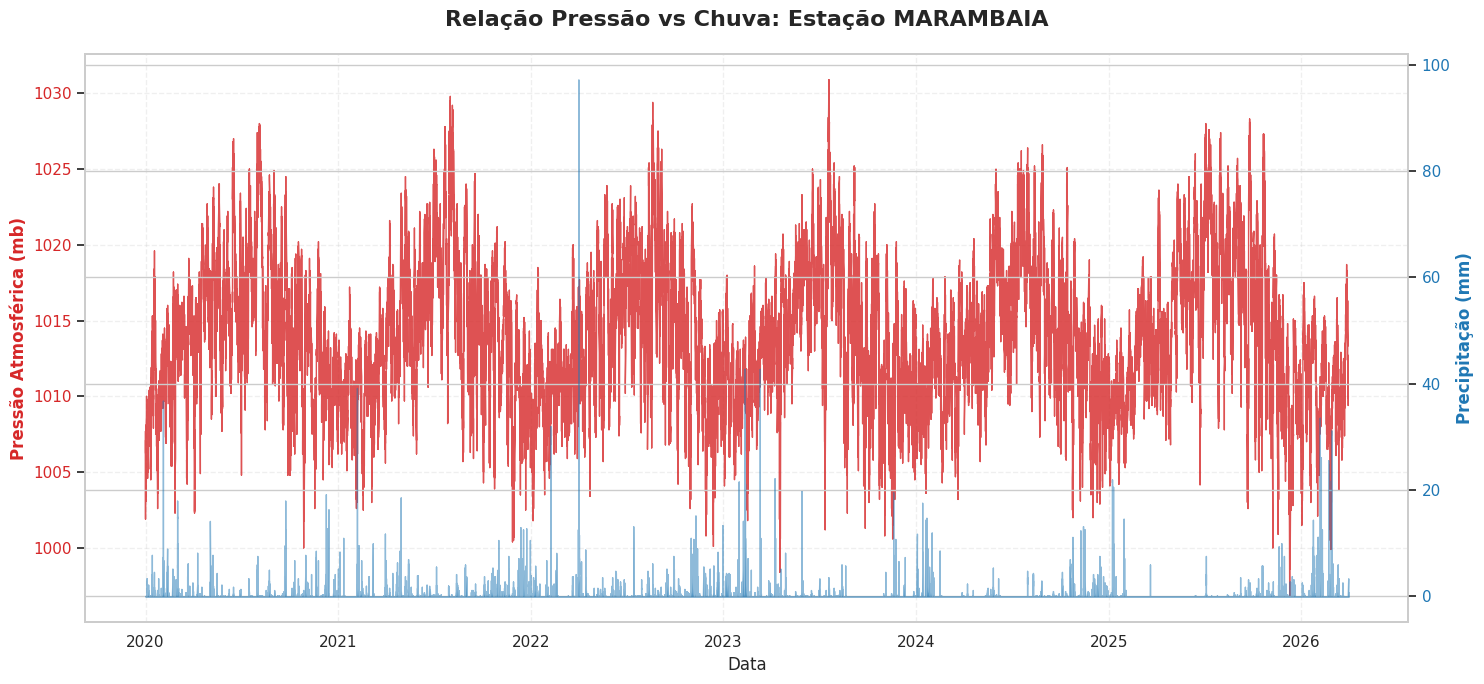

In [56]:
# 1. Filtro de Estação (Escolha uma para o gráfico ficar legível)
estacao_alvo = estacoes[0]
df_plot = df[df['estacao'] == estacao_alvo].copy()

# 2. Limpeza de Outliers (Essencial para não achatar o gráfico)
df_plot = df_plot[df_plot['pressao_atmosferica_ao_nivel_da_estacao_horaria_mb'] > 800]

# --- Início da Plotagem ---
fig, ax1 = plt.subplots(figsize=(15, 7))

# Eixo 1: Pressão Atmosférica (Linha Vermelha)
color_press = 'tab:red'
ax1.set_xlabel('Data', fontsize=12)
ax1.set_ylabel('Pressão Atmosférica (mb)', color=color_press, fontsize=12, fontweight='bold')
# Como a Data é o index, usamos df_plot.index no eixo X
ax1.plot(df_plot.index, df_plot['pressao_atmosferica_ao_nivel_da_estacao_horaria_mb'],
         color=color_press, linewidth=1, alpha=0.8, label='Pressão')
ax1.tick_params(axis='y', labelcolor=color_press)

# Eixo 2: Precipitação (Área Azul)
ax2 = ax1.twinx()
color_precip = 'tab:blue'
ax2.set_ylabel('Precipitação (mm)', color=color_precip, fontsize=12, fontweight='bold')
ax2.fill_between(df_plot.index, df_plot['precipitacao_total_horario_mm'],
                 color=color_precip, alpha=0.5, label='Chuva')
ax2.tick_params(axis='y', labelcolor=color_precip)

# Estética e Grade
plt.title(f'Relação Pressão vs Chuva: Estação {estacao_alvo}', fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()

plt.show()

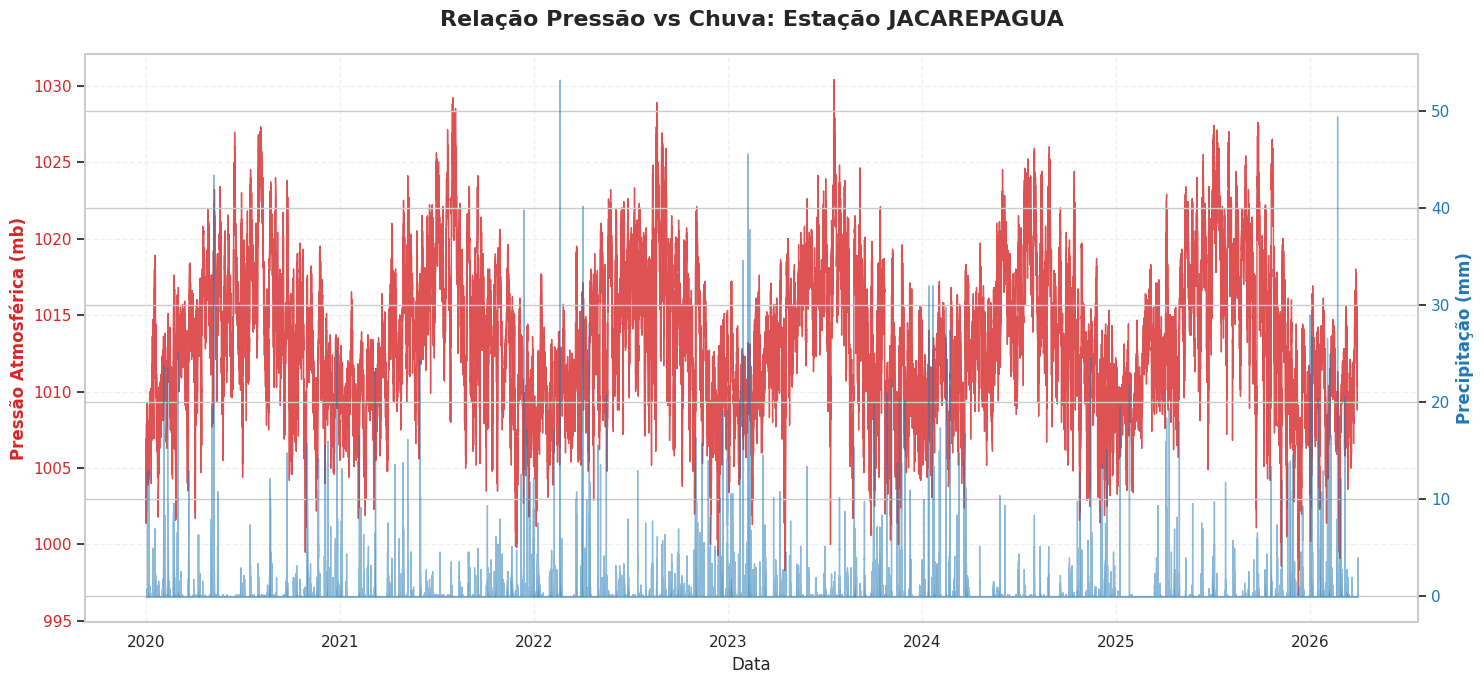

In [57]:
# 1. Filtro de Estação (Escolha uma para o gráfico ficar legível)
estacao_alvo = estacoes[1]
df_plot = df[df['estacao'] == estacao_alvo].copy()

# 2. Limpeza de Outliers (Essencial para não achatar o gráfico)
df_plot = df_plot[df_plot['pressao_atmosferica_ao_nivel_da_estacao_horaria_mb'] > 800]

# --- Início da Plotagem ---
fig, ax1 = plt.subplots(figsize=(15, 7))

# Eixo 1: Pressão Atmosférica (Linha Vermelha)
color_press = 'tab:red'
ax1.set_xlabel('Data', fontsize=12)
ax1.set_ylabel('Pressão Atmosférica (mb)', color=color_press, fontsize=12, fontweight='bold')
# Como a Data é o index, usamos df_plot.index no eixo X
ax1.plot(df_plot.index, df_plot['pressao_atmosferica_ao_nivel_da_estacao_horaria_mb'],
         color=color_press, linewidth=1, alpha=0.8, label='Pressão')
ax1.tick_params(axis='y', labelcolor=color_press)

# Eixo 2: Precipitação (Área Azul)
ax2 = ax1.twinx()
color_precip = 'tab:blue'
ax2.set_ylabel('Precipitação (mm)', color=color_precip, fontsize=12, fontweight='bold')
ax2.fill_between(df_plot.index, df_plot['precipitacao_total_horario_mm'],
                 color=color_precip, alpha=0.5, label='Chuva')
ax2.tick_params(axis='y', labelcolor=color_precip)

# Estética e Grade
plt.title(f'Relação Pressão vs Chuva: Estação {estacao_alvo}', fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()

plt.show()

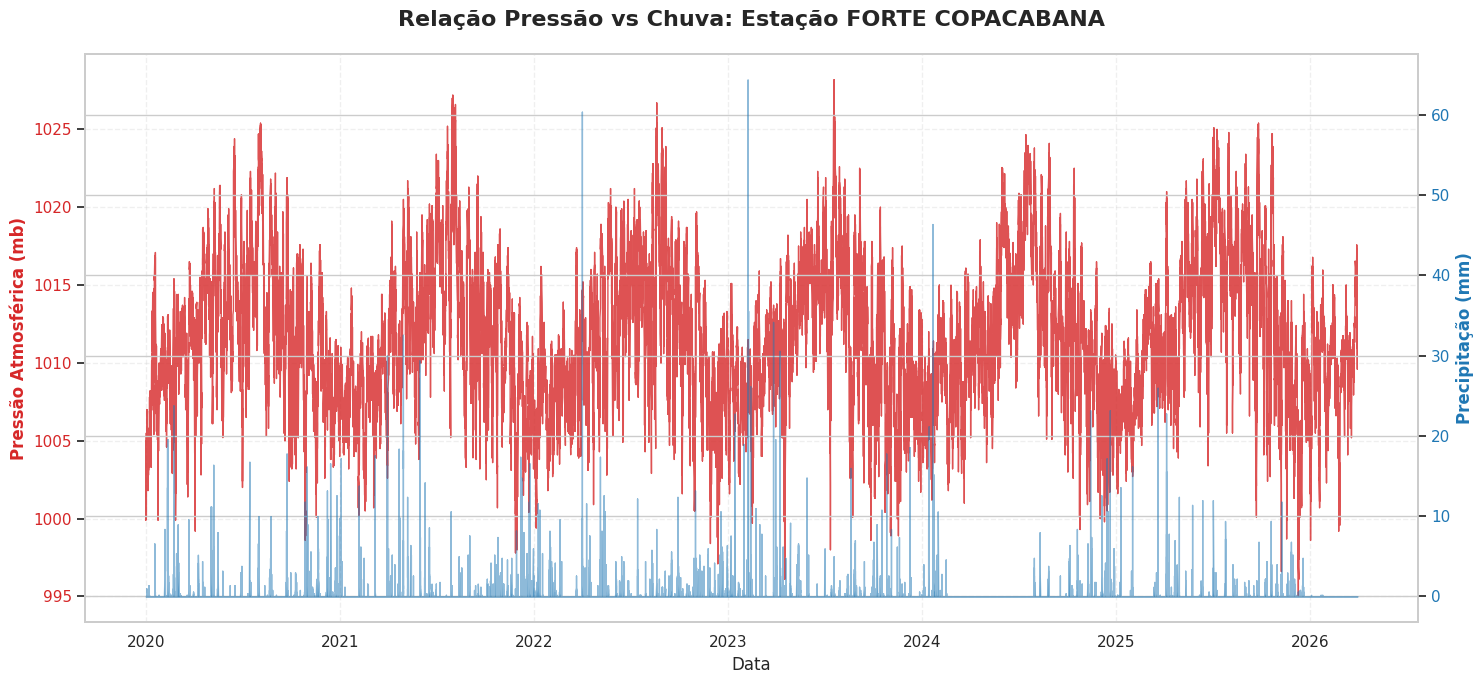

In [58]:
# 1. Filtro de Estação (Escolha uma para o gráfico ficar legível)
estacao_alvo = estacoes[2]
df_plot = df[df['estacao'] == estacao_alvo].copy()

# 2. Limpeza de Outliers (Essencial para não achatar o gráfico)
df_plot = df_plot[df_plot['pressao_atmosferica_ao_nivel_da_estacao_horaria_mb'] > 800]

# --- Início da Plotagem ---
fig, ax1 = plt.subplots(figsize=(15, 7))

# Eixo 1: Pressão Atmosférica (Linha Vermelha)
color_press = 'tab:red'
ax1.set_xlabel('Data', fontsize=12)
ax1.set_ylabel('Pressão Atmosférica (mb)', color=color_press, fontsize=12, fontweight='bold')
# Como a Data é o index, usamos df_plot.index no eixo X
ax1.plot(df_plot.index, df_plot['pressao_atmosferica_ao_nivel_da_estacao_horaria_mb'],
         color=color_press, linewidth=1, alpha=0.8, label='Pressão')
ax1.tick_params(axis='y', labelcolor=color_press)

# Eixo 2: Precipitação (Área Azul)
ax2 = ax1.twinx()
color_precip = 'tab:blue'
ax2.set_ylabel('Precipitação (mm)', color=color_precip, fontsize=12, fontweight='bold')
ax2.fill_between(df_plot.index, df_plot['precipitacao_total_horario_mm'],
                 color=color_precip, alpha=0.5, label='Chuva')
ax2.tick_params(axis='y', labelcolor=color_precip)

# Estética e Grade
plt.title(f'Relação Pressão vs Chuva: Estação {estacao_alvo}', fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()

plt.show()

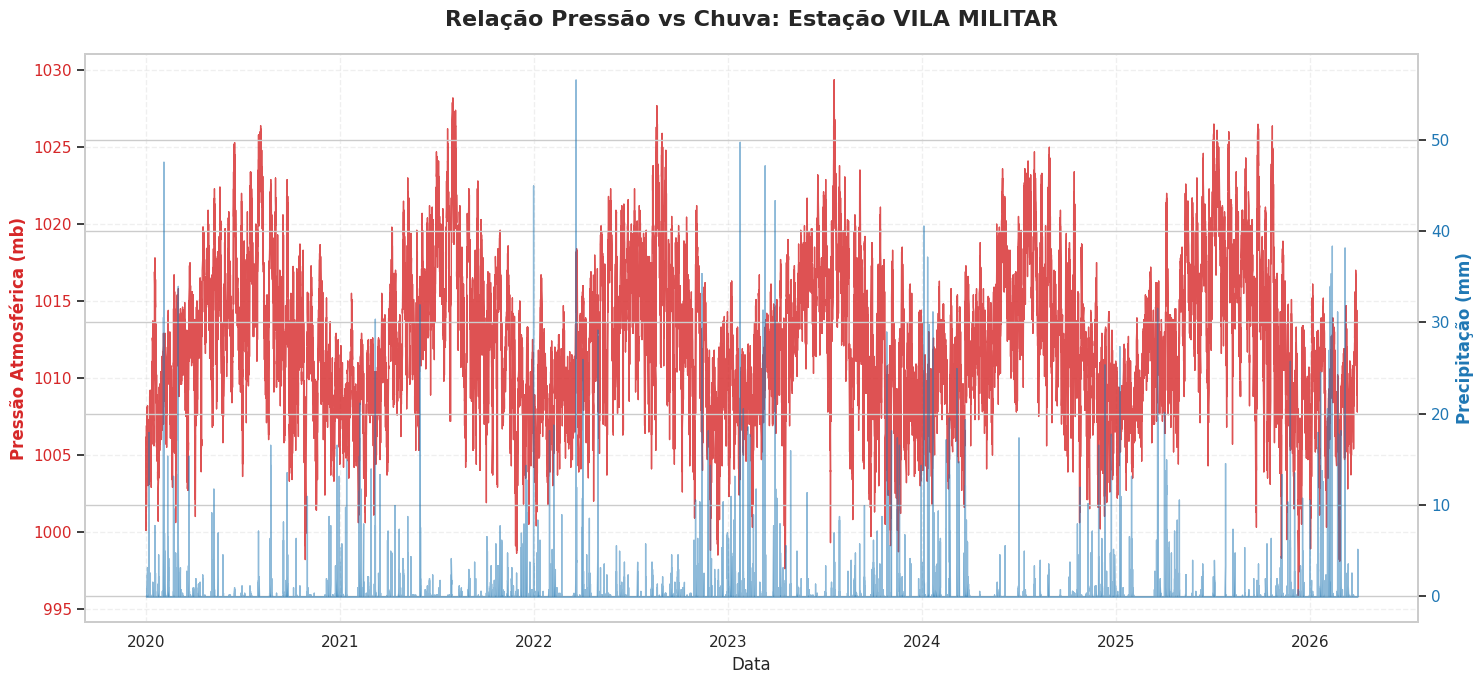

In [59]:
# 1. Filtro de Estação (Escolha uma para o gráfico ficar legível)
estacao_alvo = estacoes[3]
df_plot = df[df['estacao'] == estacao_alvo].copy()

# 2. Limpeza de Outliers (Essencial para não achatar o gráfico)
df_plot = df_plot[df_plot['pressao_atmosferica_ao_nivel_da_estacao_horaria_mb'] > 800]

# --- Início da Plotagem ---
fig, ax1 = plt.subplots(figsize=(15, 7))

# Eixo 1: Pressão Atmosférica (Linha Vermelha)
color_press = 'tab:red'
ax1.set_xlabel('Data', fontsize=12)
ax1.set_ylabel('Pressão Atmosférica (mb)', color=color_press, fontsize=12, fontweight='bold')
# Como a Data é o index, usamos df_plot.index no eixo X
ax1.plot(df_plot.index, df_plot['pressao_atmosferica_ao_nivel_da_estacao_horaria_mb'],
         color=color_press, linewidth=1, alpha=0.8, label='Pressão')
ax1.tick_params(axis='y', labelcolor=color_press)

# Eixo 2: Precipitação (Área Azul)
ax2 = ax1.twinx()
color_precip = 'tab:blue'
ax2.set_ylabel('Precipitação (mm)', color=color_precip, fontsize=12, fontweight='bold')
ax2.fill_between(df_plot.index, df_plot['precipitacao_total_horario_mm'],
                 color=color_precip, alpha=0.5, label='Chuva')
ax2.tick_params(axis='y', labelcolor=color_precip)

# Estética e Grade
plt.title(f'Relação Pressão vs Chuva: Estação {estacao_alvo}', fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()

plt.show()

### Análise de Ventos (Rosa dos Ventos)
#### Entender a origem das massas de ar (ex: brisa marítima vs. ventos de terra).

In [60]:
# 1. A Rosa dos Ventos (Os Pontos Cardeais)
# Onde o vento nasce: O gráfico mostra a direção de origem do vento.
# Se você vê uma barra grande apontando para o S (Sul), significa que o vento está vindo do mar em direção à terra.

# Orientação: O Norte (N) está no topo (0°).
# O sentido da leitura é horário: Nordeste (NE), Leste (L), Sudeste (SE), e assim por diante.

# 2. O Comprimento das Barras (Frequência)
# Quanto maior, mais comum: O comprimento da "pétala" (o quanto ela se afasta do centro) indica a frequência.

# Círculos Internos: Repare nos números em vermelho escuro (ex: 500, 1000, 1500).
# Eles indicam quantas vezes (horas) o vento soprou daquela direção específica durante todo o período analisado.

# Exemplo: Se a barra na direção SE encosta na linha do 2000,
# o vento veio do Sudeste em 2000 ocasiões diferentes.

# 3. A Escala de Cores (Intensidade de Ocorrências)
# Mapa de Cores (Magma): A cor reforça o que o comprimento da barra já diz, mas facilita a batida de olho:

# Cores Escuras (Roxo/Preto): Direções de onde o vento sopra raramente.

# Cores Vibrantes (Laranja/Amarelo): São as direções predominantes.
# O "amarelo" é o seu sinal de alerta para a origem principal das massas de ar.

# Legenda Lateral: Ela traduz a cor para o número exato de ocorrências.

# 4. Interpretando o Fenômeno (O "Pulo do Gato")
# Brisa Marítima vs. Ventos de Terra:
# No Rio, você provavelmente verá barras longas e claras vindo do quadrante S ou SE.
# Isso confirma a entrada de frentes frias e a brisa do mar que resfria a cidade à tarde.

# Ventos de Verão: Se notar barras crescendo em direção ao N ou NO,
# são ventos que vêm do interior, geralmente associados a dias muito quentes (ventos de terra).

# Resumo da leitura rápida:

# Olhe para a cor mais clara (amarela).

# Veja para qual letra ela aponta.

# Conclusão: "O vento nesta estação vem predominantemente de [Direção]."

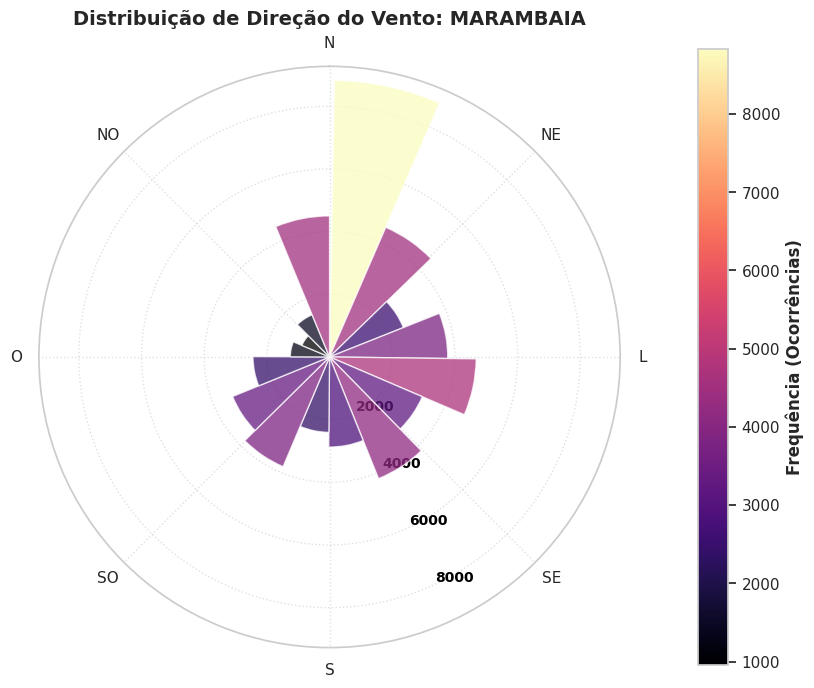

In [61]:
# 1. Preparação dos dados
estacao_alvo = estacoes[0]
df_v = df[df['estacao'] == estacao_alvo].copy().dropna(subset=['vento_direcao_horaria_gr_gr'])
direcao_rad = np.deg2rad(df_v['vento_direcao_horaria_gr_gr'])

# 2. Configuração do Plot Polar
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': 'polar'})

# Criando o histograma polar
n, bins, patches = ax.hist(direcao_rad, bins=16, edgecolor='white', alpha=0.75, zorder=2)

# 3. Mapeamento de Cores e Criação da Legenda (Colorbar)
# Criamos uma escala baseada na contagem máxima (n.max())
norm = plt.Normalize(vmin=n.min(), vmax=n.max())
mapa_cores = cm.magma

for r, bar in zip(n, patches):
    bar.set_facecolor(mapa_cores(norm(r)))

# Adicionando a Colorbar
sm = cm.ScalarMappable(cmap=mapa_cores, norm=norm)
sm.set_array([]) # Necessário para o matplotlib inicializar o objeto
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.1)
cbar.set_label('Frequência (Ocorrências)', fontsize=12, fontweight='bold')

# 4. Ajustes de Visibilidade e Orientação
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 45), labels=['N', 'NE', 'L', 'SE', 'S', 'SO', 'O', 'NO'])

# Numeração dos círculos internos
ax.set_rlabel_position(155)
plt.setp(ax.get_yticklabels(), color="black", fontsize=10, fontweight="bold")

ax.grid(True, linestyle=':', alpha=0.6, zorder=1)

plt.title(f"Distribuição de Direção do Vento: {estacao_alvo}",
          pad=30, fontsize=14, fontweight='bold')

plt.show()

In [62]:
# 1. A Posição dos Pontos (De onde vem o vento?)
# Ângulo (Direção): A posição circular do ponto indica a origem do vento.
# O Norte (N) está no topo, e o gráfico segue o sentido horário.
# Concentração de Pontos: Áreas com muitos pontos sobrepostos indicam as direções de onde o vento sopra com
# mais frequência (ex: se houver uma "nuvem" de pontos no quadrante SE, é a brisa marítima constante).

# 2. A Distância do Centro (Qual a força do vento?)
# Raio (Velocidade): Diferente do histograma, onde o comprimento era a frequência,
# aqui a distância do centro para a borda representa a velocidade ($m/s$).
# Pontos no Centro: Ventos fracos ou calmaria.
# Pontos na Extremidade: Representam as rajadas mais fortes ou ventos intensos.
# Se os pontos mais distantes estiverem todos no Sul (S), significa que as tempestades
# e ventos fortes vêm daquela direção.

# 3. A Escala de Cores (Destaque Visual)
# Cores Escuras (Roxo/Preto): Ventos de baixa velocidade.
# Cores Claras (Laranja/Amarelo): Ventos de alta velocidade.
# Utilidade: Isso ajuda a identificar rapidamente se os ventos rápidos (pontos claros) estão vindo de uma direção
#  diferente dos ventos lentos.

# 4. Transparência (alpha=0.5)
# Como os pontos são semitransparentes, as áreas mais escuras e sólidas no gráfico mostram onde há maior densidade de dados.
# Isso revela o comportamento "padrão" da estação, enquanto pontos isolados e claros nas bordas revelam eventos extremos
# (rajadas ocasionais).

# Resumo para o seu relatório:
# Direção predominante: Olhe onde está a maior densidade de pontos.

# Ventos Extremos: Olhe para os pontos mais distantes do centro e veja a cor deles na barra lateral.

# Hipótese de Copacabana: Se o gráfico mostrar muitos pontos esticados em direção ao S/SE,
# você confirmou que os ventos mais frequentes e fortes vêm do oceano.

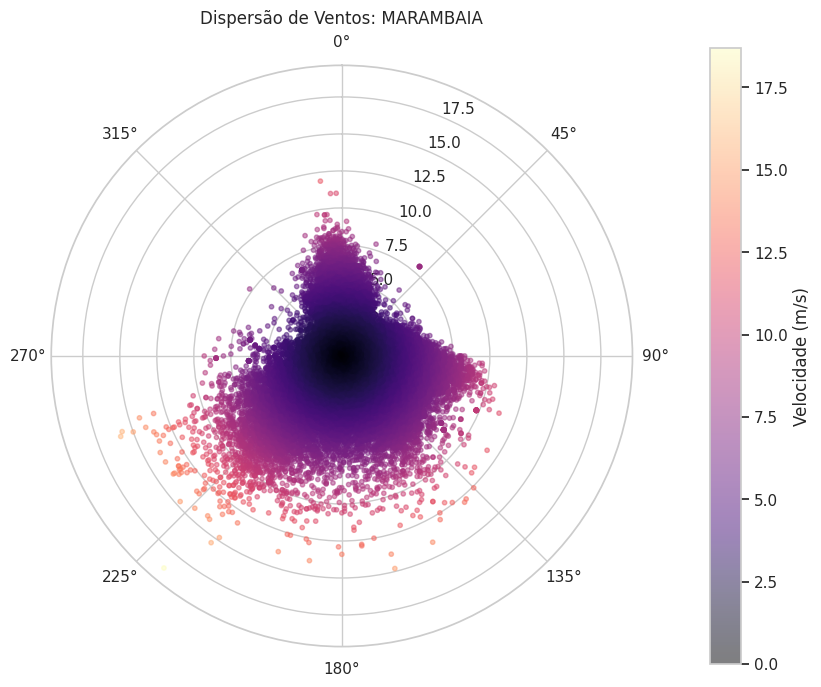

In [63]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

# x = direção em radianos, y = velocidade
c = ax.scatter(np.deg2rad(df_v['vento_direcao_horaria_gr_gr']),
               df_v['vento_velocidade_horaria_m_s'],
               c=df_v['vento_velocidade_horaria_m_s'], # Cor pela velocidade
               cmap='magma',
               alpha=0.5,
               s=10) # Tamanho do ponto

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

# Barra de cor lateral para escala de velocidade
plt.colorbar(c, label='Velocidade (m/s)', pad=0.1)

plt.title(f"Dispersão de Ventos: {estacao_alvo}", pad=30)
plt.show()

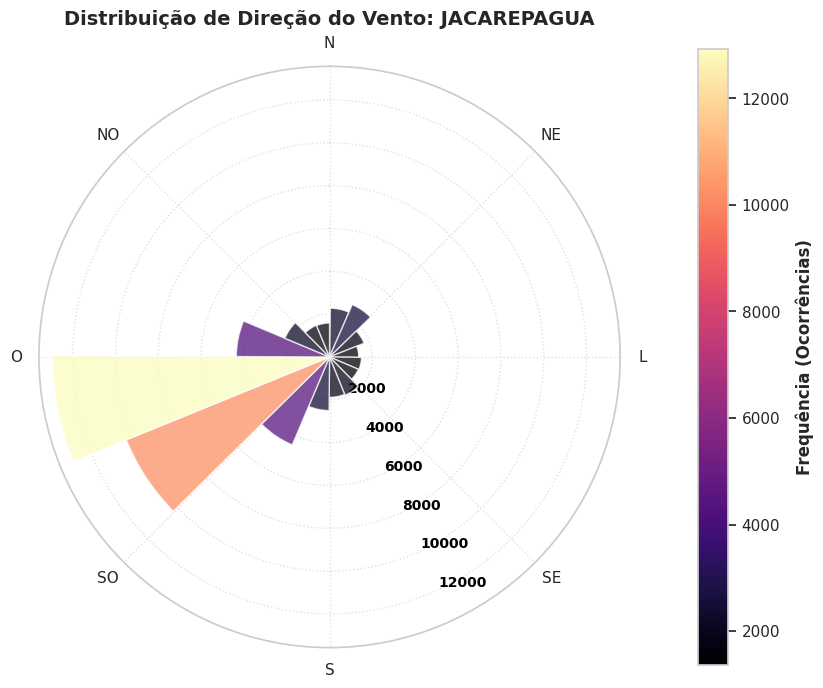

In [64]:
# 1. Preparação dos dados
estacao_alvo = estacoes[1]
df_v = df[df['estacao'] == estacao_alvo].copy().dropna(subset=['vento_direcao_horaria_gr_gr'])
direcao_rad = np.deg2rad(df_v['vento_direcao_horaria_gr_gr'])

# 2. Configuração do Plot Polar
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': 'polar'})

# Criando o histograma polar
n, bins, patches = ax.hist(direcao_rad, bins=16, edgecolor='white', alpha=0.75, zorder=2)

# 3. Mapeamento de Cores e Criação da Legenda (Colorbar)
# Criamos uma escala baseada na contagem máxima (n.max())
norm = plt.Normalize(vmin=n.min(), vmax=n.max())
mapa_cores = cm.magma

for r, bar in zip(n, patches):
    bar.set_facecolor(mapa_cores(norm(r)))

# Adicionando a Colorbar
sm = cm.ScalarMappable(cmap=mapa_cores, norm=norm)
sm.set_array([]) # Necessário para o matplotlib inicializar o objeto
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.1)
cbar.set_label('Frequência (Ocorrências)', fontsize=12, fontweight='bold')

# 4. Ajustes de Visibilidade e Orientação
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 45), labels=['N', 'NE', 'L', 'SE', 'S', 'SO', 'O', 'NO'])

# Numeração dos círculos internos
ax.set_rlabel_position(155)
plt.setp(ax.get_yticklabels(), color="black", fontsize=10, fontweight="bold")

ax.grid(True, linestyle=':', alpha=0.6, zorder=1)

plt.title(f"Distribuição de Direção do Vento: {estacao_alvo}",
          pad=30, fontsize=14, fontweight='bold')

plt.show()

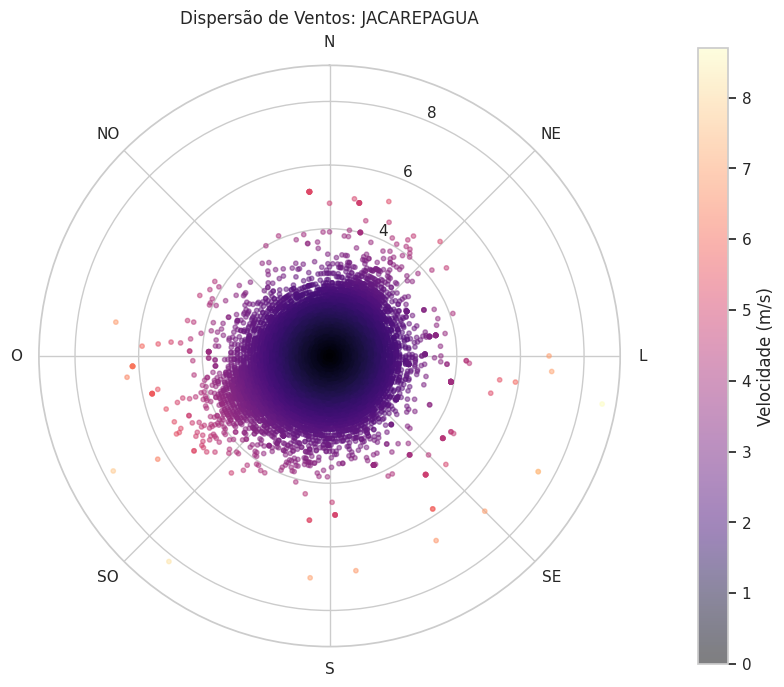

In [65]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

# x = direção em radianos, y = velocidade
c = ax.scatter(np.deg2rad(df_v['vento_direcao_horaria_gr_gr']),
               df_v['vento_velocidade_horaria_m_s'],
               c=df_v['vento_velocidade_horaria_m_s'], # Cor pela velocidade
               cmap='magma',
               alpha=0.5,
               s=10) # Tamanho do ponto

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 45), labels=['N', 'NE', 'L', 'SE', 'S', 'SO', 'O', 'NO'])

# Barra de cor lateral para escala de velocidade
plt.colorbar(c, label='Velocidade (m/s)', pad=0.1)

plt.title(f"Dispersão de Ventos: {estacao_alvo}", pad=30)
plt.show()

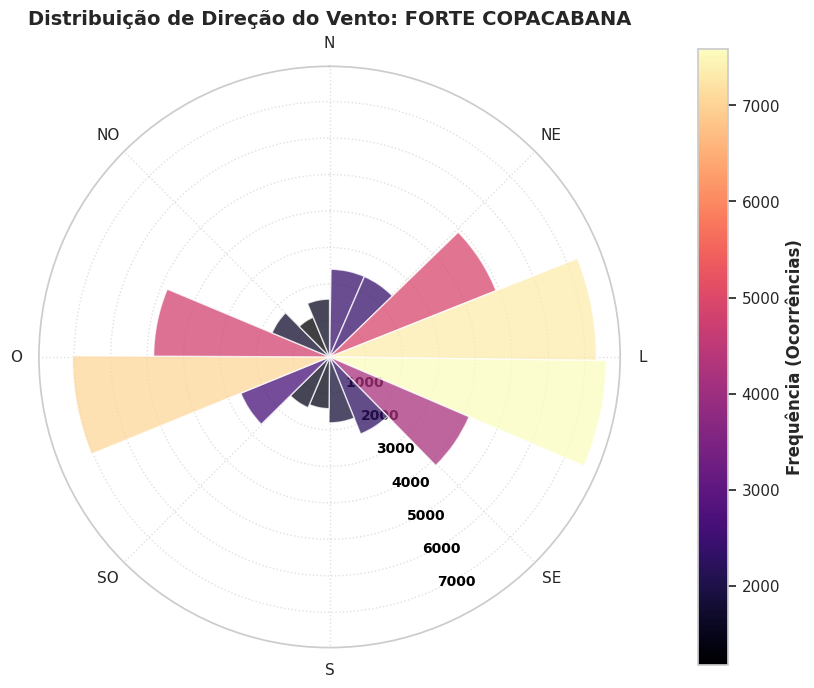

In [66]:
# 1. Preparação dos dados
estacao_alvo = estacoes[2]
df_v = df[df['estacao'] == estacao_alvo].copy().dropna(subset=['vento_direcao_horaria_gr_gr'])
direcao_rad = np.deg2rad(df_v['vento_direcao_horaria_gr_gr'])

# 2. Configuração do Plot Polar
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': 'polar'})

# Criando o histograma polar
n, bins, patches = ax.hist(direcao_rad, bins=16, edgecolor='white', alpha=0.75, zorder=2)

# 3. Mapeamento de Cores e Criação da Legenda (Colorbar)
# Criamos uma escala baseada na contagem máxima (n.max())
norm = plt.Normalize(vmin=n.min(), vmax=n.max())
mapa_cores = cm.magma

for r, bar in zip(n, patches):
    bar.set_facecolor(mapa_cores(norm(r)))

# Adicionando a Colorbar
sm = cm.ScalarMappable(cmap=mapa_cores, norm=norm)
sm.set_array([]) # Necessário para o matplotlib inicializar o objeto
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.1)
cbar.set_label('Frequência (Ocorrências)', fontsize=12, fontweight='bold')

# 4. Ajustes de Visibilidade e Orientação
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 45), labels=['N', 'NE', 'L', 'SE', 'S', 'SO', 'O', 'NO'])

# Numeração dos círculos internos
ax.set_rlabel_position(155)
plt.setp(ax.get_yticklabels(), color="black", fontsize=10, fontweight="bold")

ax.grid(True, linestyle=':', alpha=0.6, zorder=1)

plt.title(f"Distribuição de Direção do Vento: {estacao_alvo}",
          pad=30, fontsize=14, fontweight='bold')

plt.show()

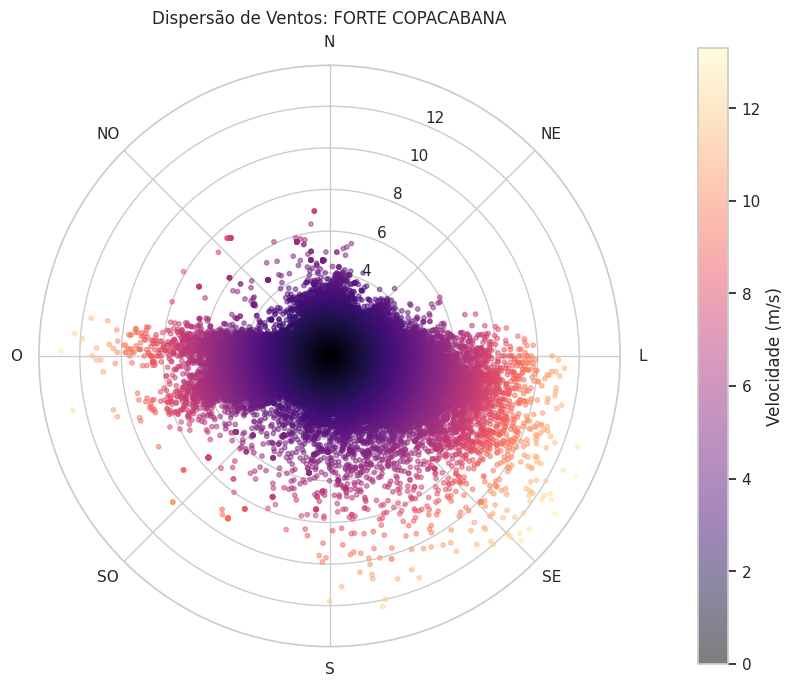

In [67]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

# x = direção em radianos, y = velocidade
c = ax.scatter(np.deg2rad(df_v['vento_direcao_horaria_gr_gr']),
               df_v['vento_velocidade_horaria_m_s'],
               c=df_v['vento_velocidade_horaria_m_s'], # Cor pela velocidade
               cmap='magma',
               alpha=0.5,
               s=10) # Tamanho do ponto

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 45), labels=['N', 'NE', 'L', 'SE', 'S', 'SO', 'O', 'NO'])

# Barra de cor lateral para escala de velocidade
plt.colorbar(c, label='Velocidade (m/s)', pad=0.1)

plt.title(f"Dispersão de Ventos: {estacao_alvo}", pad=30)
plt.show()

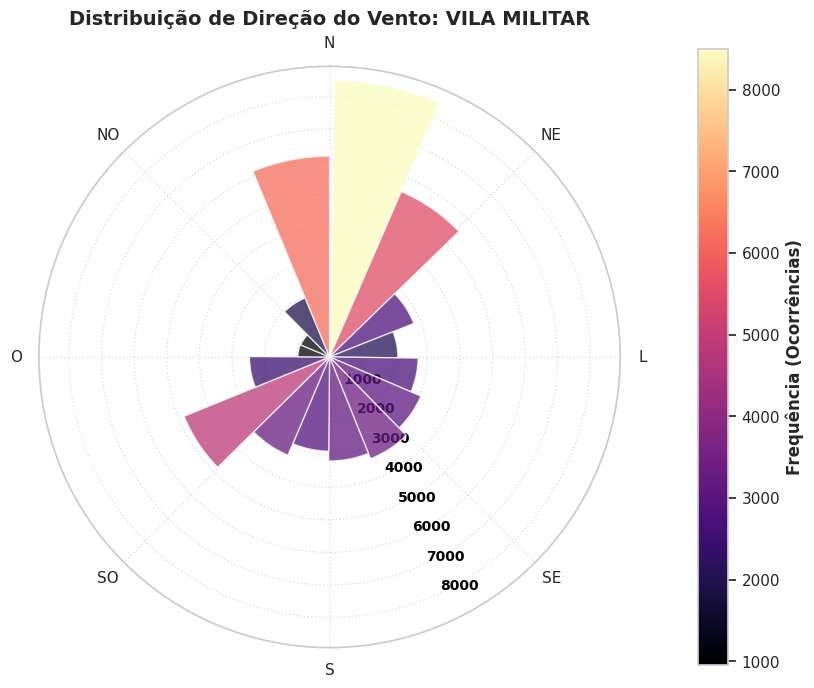

In [68]:
# 1. Preparação dos dados
estacao_alvo = estacoes[3]
df_v = df[df['estacao'] == estacao_alvo].copy().dropna(subset=['vento_direcao_horaria_gr_gr'])
direcao_rad = np.deg2rad(df_v['vento_direcao_horaria_gr_gr'])

# 2. Configuração do Plot Polar
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': 'polar'})

# Criando o histograma polar
n, bins, patches = ax.hist(direcao_rad, bins=16, edgecolor='white', alpha=0.75, zorder=2)

# 3. Mapeamento de Cores e Criação da Legenda (Colorbar)
# Criamos uma escala baseada na contagem máxima (n.max())
norm = plt.Normalize(vmin=n.min(), vmax=n.max())
mapa_cores = cm.magma

for r, bar in zip(n, patches):
    bar.set_facecolor(mapa_cores(norm(r)))

# Adicionando a Colorbar
sm = cm.ScalarMappable(cmap=mapa_cores, norm=norm)
sm.set_array([]) # Necessário para o matplotlib inicializar o objeto
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.1)
cbar.set_label('Frequência (Ocorrências)', fontsize=12, fontweight='bold')

# 4. Ajustes de Visibilidade e Orientação
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 45), labels=['N', 'NE', 'L', 'SE', 'S', 'SO', 'O', 'NO'])

# Numeração dos círculos internos
ax.set_rlabel_position(155)
plt.setp(ax.get_yticklabels(), color="black", fontsize=10, fontweight="bold")

ax.grid(True, linestyle=':', alpha=0.6, zorder=1)

plt.title(f"Distribuição de Direção do Vento: {estacao_alvo}",
          pad=30, fontsize=14, fontweight='bold')

plt.show()

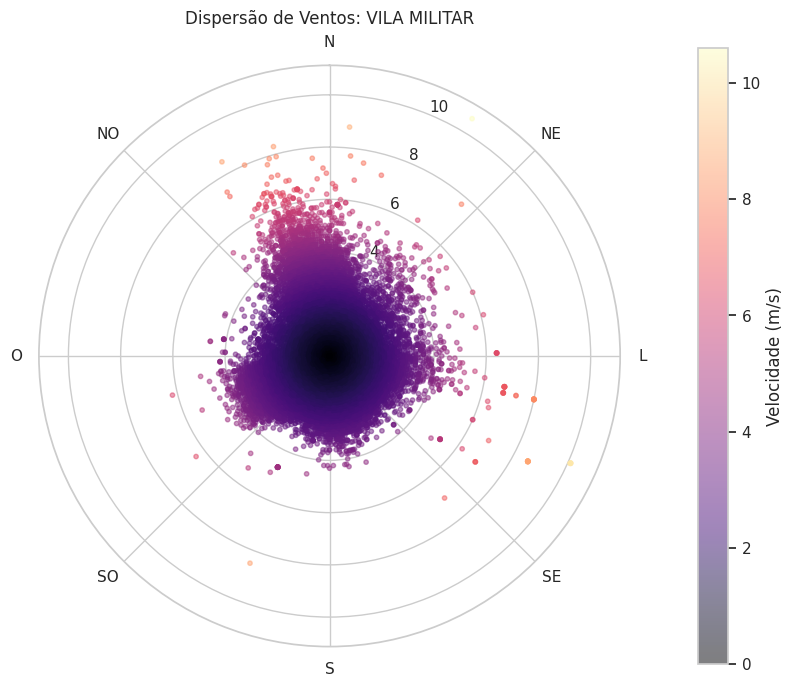

In [69]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

# x = direção em radianos, y = velocidade
c = ax.scatter(np.deg2rad(df_v['vento_direcao_horaria_gr_gr']),
               df_v['vento_velocidade_horaria_m_s'],
               c=df_v['vento_velocidade_horaria_m_s'], # Cor pela velocidade
               cmap='magma',
               alpha=0.5,
               s=10) # Tamanho do ponto

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 45), labels=['N', 'NE', 'L', 'SE', 'S', 'SO', 'O', 'NO'])

# Barra de cor lateral para escala de velocidade
plt.colorbar(c, label='Velocidade (m/s)', pad=0.1)

plt.title(f"Dispersão de Ventos: {estacao_alvo}", pad=30)
plt.show()

# Salvando df

In [70]:
df.shape, df.columns

((219072, 30),
 Index(['hora_utc', 'precipitacao_total_horario_mm',
        'pressao_atmosferica_ao_nivel_da_estacao_horaria_mb',
        'pressao_atmosferica_max_na_hora_ant_aut_mb',
        'pressao_atmosferica_min_na_hora_ant_aut_mb', 'radiacao_global_kj_m2',
        'temperatura_do_ar_bulbo_seco_horaria_c',
        'temperatura_do_ponto_de_orvalho_c',
        'temperatura_maxima_na_hora_ant_aut_c',
        'temperatura_minima_na_hora_ant_aut_c',
        'temperatura_orvalho_max_na_hora_ant_aut_c',
        'temperatura_orvalho_min_na_hora_ant_aut_c',
        'umidade_rel_max_na_hora_ant_aut', 'umidade_rel_min_na_hora_ant_aut',
        'umidade_relativa_do_ar_horaria', 'vento_direcao_horaria_gr_gr',
        'vento_rajada_maxima_m_s', 'vento_velocidade_horaria_m_s', 'codigo',
        'estacao', 'YEAR', 'MONTH', 'DAY_WEEK', 'DAY_MONTH', 'DAY_MONTH_START',
        'DAY_MONTH_END', 'DAY_QUARTER_START', 'DAY_QUARTER_END',
        'DAY_YEAR_START', 'DAY_YEAR_END'],
       dtype='object'))

In [71]:
df.isna().sum().sum()

np.int64(0)

In [72]:
df.index

DatetimeIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01',
               ...
               '2026-03-31', '2026-03-31', '2026-03-31', '2026-03-31',
               '2026-03-31', '2026-03-31', '2026-03-31', '2026-03-31',
               '2026-03-31', '2026-03-31'],
              dtype='datetime64[ns]', name='Data', length=219072, freq=None)

In [73]:
path_inmet_rj = '/content/drive/MyDrive/ML-UFF/inmet_2020_2026_analise.csv'
save_data_frame(df, path_inmet_rj)